In [1]:
import os
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d
from scipy.integrate import quad
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['agg.path.chunksize'] = 10000

# Set universal font properties
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})


In [2]:
import bifft
import pickle
np.complex = complex

Initiating args for bispec code...


## Visualization

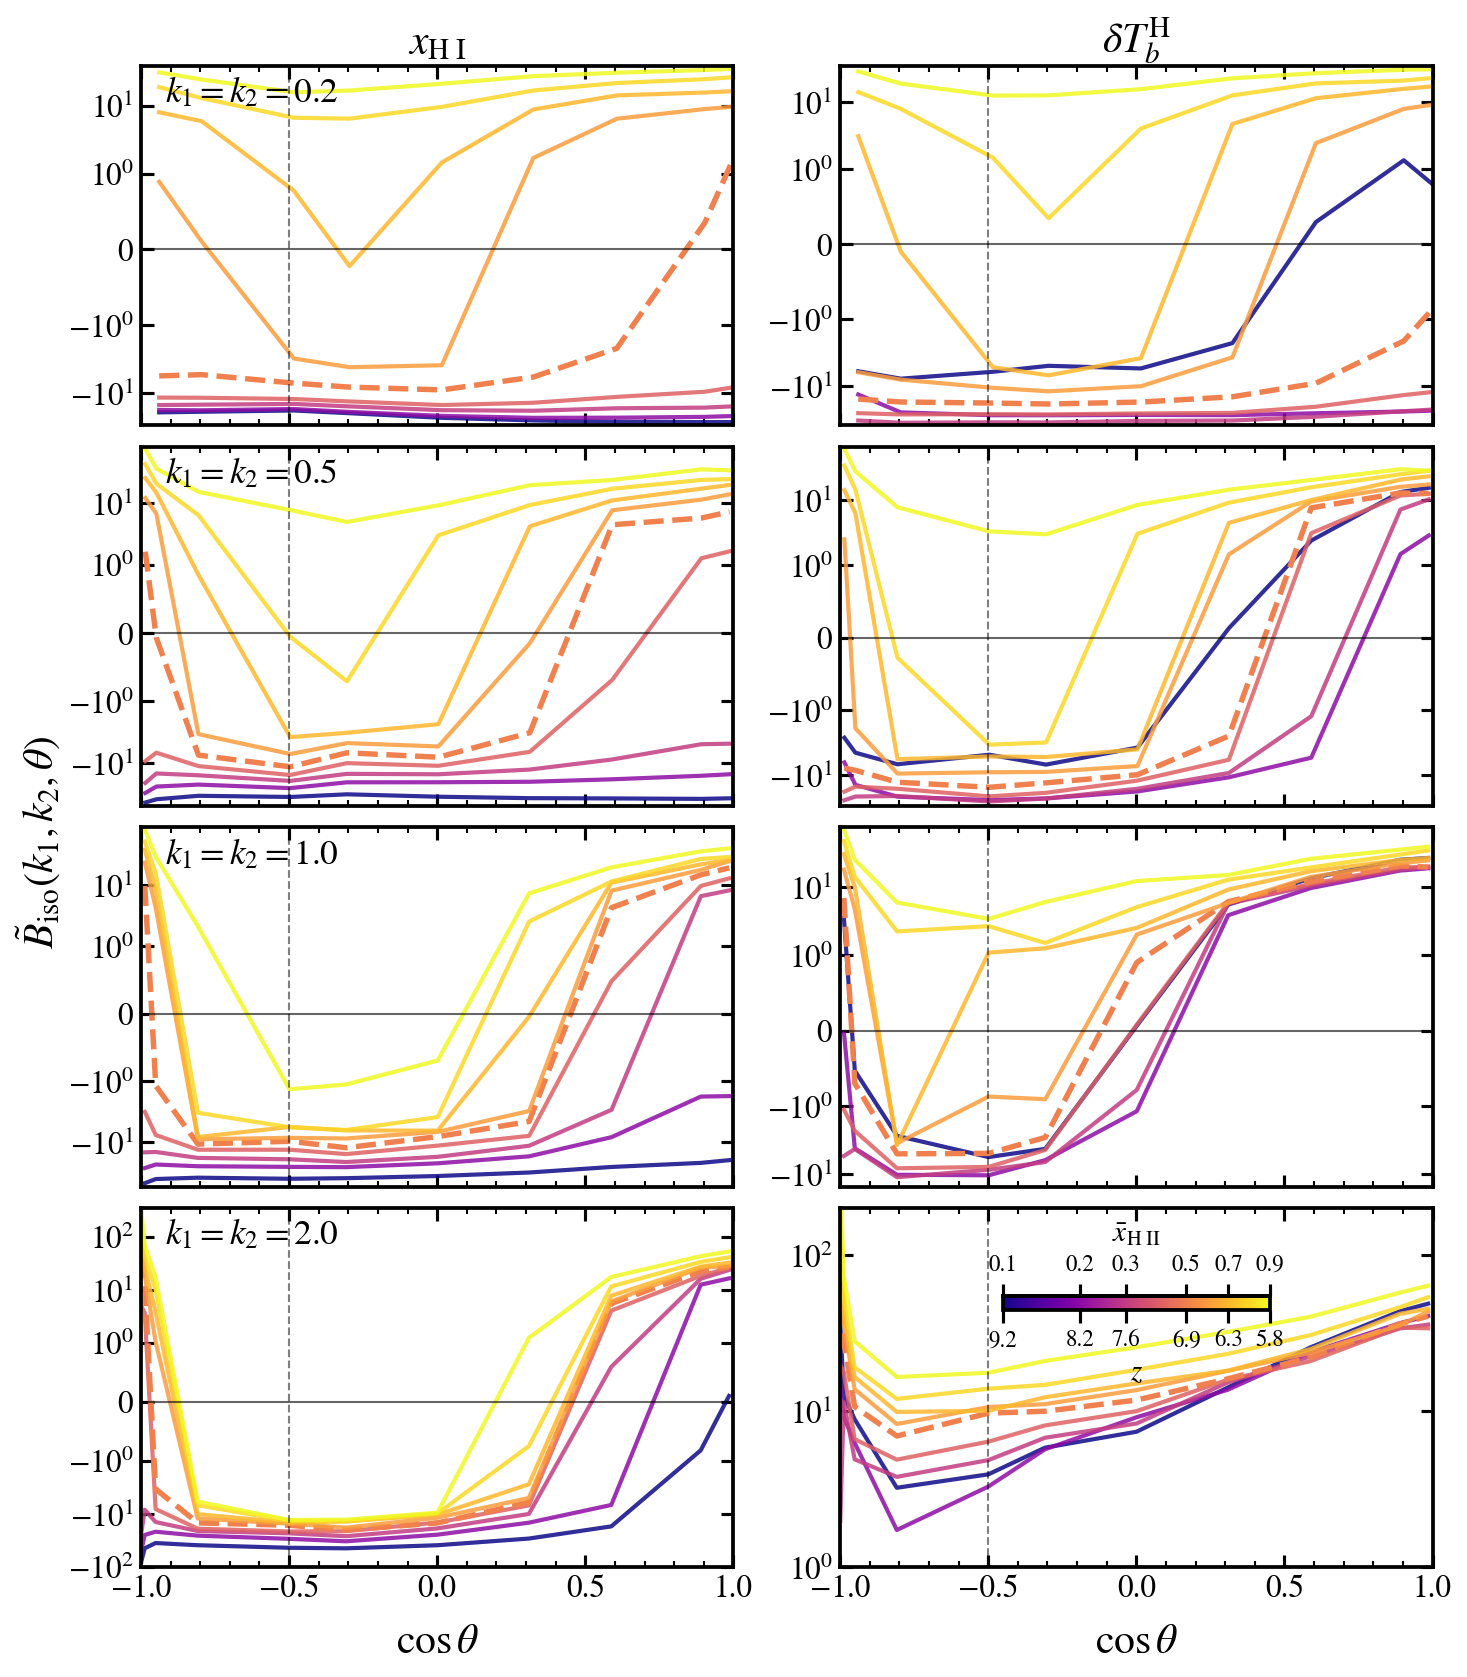

In [3]:
import cmasher as cmr
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================
# Configuration
# =====================================

snaps = [177, 203, 220, 242, 264, 283, 300, 318, 338]

z_map = {
    177: 9.17,
    203: 8.20,
    220: 7.62,
    242: 7.20,
    264: 6.87,
    283: 6.59,
    300: 6.34,
    318: 6.10,
    338: 5.83
}

base = "/orcd/data/mvogelsb/004/chcho/PS_21cm/bispec/final_Tb"
#"/orcd/data/mvogelsb/004/chcho/PS_21cm/bispec"

k1_list = [0.2, 0.5, 1.0, 2.0] #1.5

# =====================================
# Publication-quality matplotlib style
# =====================================

mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,

    "axes.linewidth": 1.8,

    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "figure.dpi": 150,
    "savefig.dpi": 300,
})

# =====================================
# Colormap
# =====================================

cmap = plt.cm.plasma_r #Spectral_r

norm = mpl.colors.Normalize(
    vmin=5.83,
    vmax=9.17
)

# =====================================
# Figure
# =====================================

fig, axes = plt.subplots(
    len(k1_list),
    2,
    figsize=(10.5, 11.5),
    sharex=True
)

# =====================================
# Loop over rows
# =====================================

for row, k1 in enumerate(k1_list):

    k2 = k1

    # =================================
    # LEFT : f_HII
    # =================================

    ax = axes[row, 0]

    for snap in snaps:

        file = f"{base}/bispec_iso_{snap}_{k1}_f_HII.txt"

        if not os.path.exists(file):
            continue

        data = np.loadtxt(file)

        k3 = data[:, 0]
        B  = data[:, 1]

        cos_theta = (
            (k3**2 - k1**2 - k2**2)
            / (2 * k1 * k2)
        )

        cos_theta = np.clip(
            cos_theta,
            -1.0,
            1.0
        )

        idx = np.argsort(cos_theta)

        special = (snap == 264)

        ax.plot(
            cos_theta[idx],
            B[idx],
            color=cmap(norm(z_map[snap])),
            linewidth=2.6 if special else 2.0,
            linestyle="--" if special else "-",
            alpha=1.0 if special else 0.85
        )

    ax.text(
        0.04,
        0.90,
        rf"$k_1 = k_2 = {k1}$",
        transform=ax.transAxes,
        fontsize=17
    )

    # =================================
    # RIGHT : Tb
    # =================================

    ax = axes[row, 1]

    for snap in snaps:

        file = f"{base}/bispec_iso_{snap}_{k1}_Tb.txt"

        if not os.path.exists(file):
            continue

        data = np.loadtxt(file)

        k3 = data[:, 0]
        B  = data[:, 1]

        cos_theta = (
            (k3**2 - k1**2 - k2**2)
            / (2 * k1 * k2)
        )

        cos_theta = np.clip(
            cos_theta,
            -1.0,
            1.0
        )

        idx = np.argsort(cos_theta)

        special = (snap == 264)

        ax.plot(
            cos_theta[idx],
            B[idx],
            color=cmap(norm(z_map[snap])),
            linewidth=2.6 if special else 2.0,
            linestyle="--" if special else "-",
            alpha=1.0 if special else 0.85
        )

# =====================================
# Common formatting
# =====================================

for row in range(len(k1_list)):

    # -------------------------------
    # LEFT
    # -------------------------------

    ax_left = axes[row, 0]

    ax_left.set_xlim(-1, 1)

    ax_left.set_yscale(
        "symlog",
        linthresh=1
    )

    ax_left.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=15
    )

    ax_left.minorticks_on()

    ax_left.axvline(
        x=-0.5,
        linestyle="--",
        color="black",
        linewidth=1.0,
        alpha=0.5
    )

    ax_left.axhline(
        y=0,
        linestyle="-",
        color="black",
        linewidth=1.0,
        alpha=0.6
    )

    ax_left.tick_params(
        axis="y",
        labelleft=True
    )

    # -------------------------------
    # RIGHT
    # -------------------------------

    ax_right = axes[row, 1]

    ax_right.set_xlim(-1, 1)

    ax_right.set_yscale(
        "symlog",
        linthresh=1
    )

    ax_right.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=15
    )

    ax_right.minorticks_on()

    ax_right.axvline(
        x=-0.5,
        linestyle="--",
        color="black",
        linewidth=1.0,
        alpha=0.5
    )

    ax_right.axhline(
        y=0,
        linestyle="-",
        color="black",
        linewidth=1.0,
        alpha=0.6
    )

    ax_right.tick_params(
        axis="y",
        labelleft=True
    )

# =====================================
# Optional fixed last-row range
# =====================================

axes[-1, 1].set_ylim(1, 200)

# =====================================
# Remove repeated x labels
# =====================================

for ax in axes[:-1, :].flatten():
    ax.tick_params(
        axis="x",
        labelbottom=False
    )

# =====================================
# Column titles
# =====================================

axes[0, 0].set_title(
    r"$x_{\mathrm{H\ I}}$",
    fontsize=20
)

axes[0, 1].set_title(
    r"$\delta T^{\rm H}_b$",
    fontsize=20
)

# =====================================
# Panel labels
# =====================================
"""
axes[0, 0].text(
    0.03,
    0.93,
    r"(a)",
    transform=axes[0, 0].transAxes,
    fontsize=18,
    ha="left",
    va="top"
)

axes[0, 1].text(
    0.03,
    0.93,
    r"(b)",
    transform=axes[0, 1].transAxes,
    fontsize=18,
    ha="left",
    va="top"
)
"""

# --------------------------------
# Small horizontal embedded colorbar inside right panel
# with second axis for x̄_HII
# --------------------------------

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cax = inset_axes(
    ax_right,
    width="45%",     # horizontal length
    height="4%",     # thin height
    loc="upper center",
    borderpad=3.0
)

# Main colorbar (redshift z)
cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)

cbar.set_label(r"$z$", fontsize=14)
cbar.ax.tick_params(labelsize=11)

# Reverse so high-z is left, low-z is right
#cbar.ax.invert_xaxis()


# --------------------------------
# Second top axis: x̄_HII
# using exact z ↔ x̄_HII mapping
# --------------------------------

# exact physical mapping
xhii_vals = np.array([
    0.90,
    #0.80,
    0.70,
    #0.60,
    0.50,
    #0.40,
    0.30,
    0.20,
    0.10
])

z_match = np.array([
    5.826679,
    #6.099902,
    6.342011,
    #6.592783,
    6.872631,
    #7.204283,
    7.624910,
    8.207879,
    9.170129
])

# --------------------------------
# Bottom ticks = redshift z
# --------------------------------

cbar.set_ticks(z_match)
cbar.set_ticklabels([f"{z:.1f}" for z in z_match])

# reverse so high-z is left
cbar.ax.invert_xaxis()

# --------------------------------
# Top ticks = x̄_HII
# --------------------------------

top_ax = cbar.ax.twiny()
top_ax.set_xlim(cbar.ax.get_xlim())

top_ax.set_xticks(z_match)
top_ax.set_xticklabels(
    [f"{x:.1f}" for x in xhii_vals],
    fontsize=11
)

top_ax.set_xlabel(
    r"$\bar{x}_{\mathrm{H \ II}}$",
    fontsize=14,
    labelpad=6
)

# --------------------------------
# nicer ticks
# --------------------------------

for ax in [ax_left, ax_right]:

    ax.tick_params(
        which='both',
        direction='in',
        top=True,
        right=True
    )

    ax.minorticks_on()


# =====================================
# Shared labels
# =====================================

# left column x-label
axes[-1, 0].set_xlabel(
    r"$\cos\theta$",
    fontsize=20,
    labelpad=10
)

# right column x-label
axes[-1, 1].set_xlabel(
    r"$\cos\theta$",
    fontsize=20,
    labelpad=10
)

fig.supylabel(
    r"$\tilde{B}_{\mathrm{iso}}(k_1,k_2,\theta)$", #\ [{\rm mK}^3]
    fontsize=20,
    x=0.02
)

# =====================================
# Better spacing (instead of tight_layout)
# =====================================

fig.subplots_adjust(
    left=0.10,
    right=0.92,
    bottom=0.08,
    top=0.95,
    hspace=0.06,
    wspace=0.18
)

# =====================================
# Save
# =====================================

# plt.savefig(
#     "bispectrum_publication.pdf",
#     bbox_inches="tight"
# )

plt.show()

/tmp/ipykernel_51289/2333914129.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


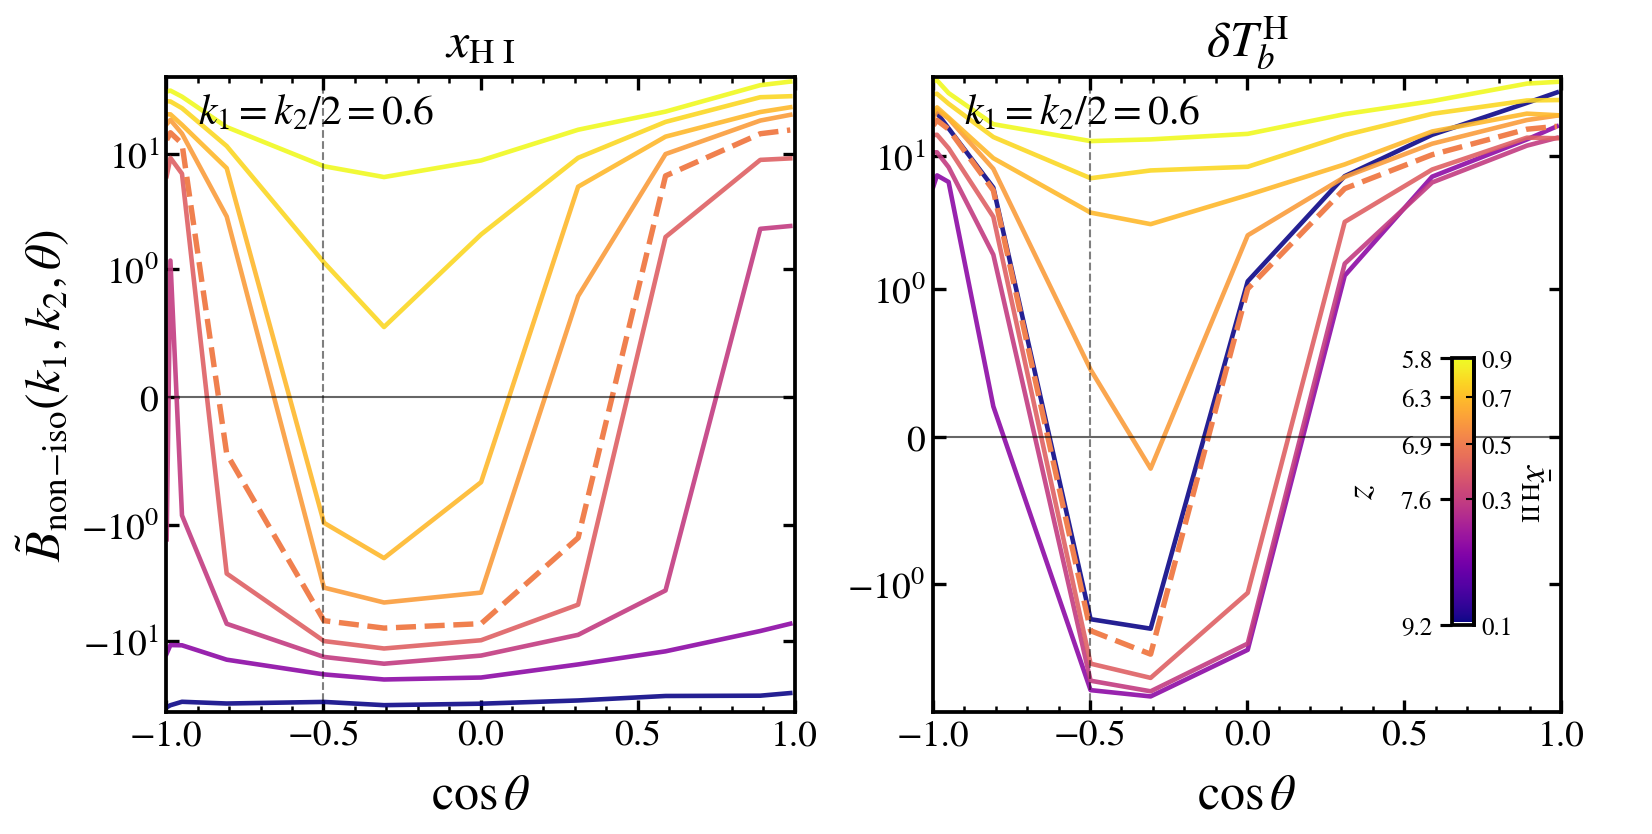

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================
# Configuration
# =====================================

snaps = [177, 203, 220, 242, 264, 283, 300, 318, 338]

z_map = {
    177: 9.17,
    203: 8.20,
    220: 7.62,
    242: 7.20,
    264: 6.87,
    283: 6.59,
    300: 6.34,
    318: 6.10,
    338: 5.83
}

k1 = 0.6
k2 = k1*2

base = "/orcd/data/mvogelsb/004/chcho/PS_21cm/bispec/final_Tb"

# =====================================
# Publication-quality matplotlib style
# =====================================

mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,

    "axes.linewidth": 1.8,

    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "figure.dpi": 150,
    "savefig.dpi": 300,
})

# =====================================
# Colormap
# =====================================

cmap = plt.cm.plasma_r
norm = mpl.colors.Normalize(
    vmin=5.83,
    vmax=9.17
)

sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])

# =====================================
# Figure
# =====================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.5),
    gridspec_kw={
        "wspace": 0.22
    }
)

# =====================================
# LEFT PANEL : f_HII
# =====================================

ax = axes[0]

for snap in snaps:

    file = f"{base}/bispec_non_iso_{snap}_{k1}_{k2}_f_HII.txt"

    if not os.path.exists(file):
        continue

    data = np.loadtxt(file)

    #k1 = 0.4
    #k2 = 0.8
    k3 = data[:, 0]
    B = data[:, 1]

    cos_theta = (
        (k3**2 - k1**2 - k2**2)
        / (2 * k1 * k2)
    )

    cos_theta = np.clip(
        cos_theta,
        -1.0,
        1.0
    )

    idx = np.argsort(cos_theta)

    special = (snap == 264)

    ax.plot(
        cos_theta[idx],
        B[idx],
        color=cmap(norm(z_map[snap])),
        linewidth=2.6 if special else 2.2,
        linestyle="--" if special else "-",
        alpha=1.0 if special else 0.9
    )

ax.set_xlim(-1, 1)

ax.set_yscale(
    "symlog",
    linthresh=1
)

ax.set_ylabel(
    r"$\tilde{B}_{\mathrm{non\!-\!iso}}(k_1,k_2,\theta)$", #\ [{\rm mK}^3]
    fontsize=24
)

ax.set_title(
    r"$x_{\mathrm{H\ I}}$",
    fontsize=24,
    pad=10
)

ax.text(
    0.05,
    0.975,
    f"$k_1 = k_2/2 = {k1}$",
    transform=ax.transAxes,
    fontsize=20,
    ha="left",
    va="top"
)

ax.axvline(
    x=-0.5,
    linestyle="--",
    color="black",
    linewidth=1.0,
    alpha=0.5
)

ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=1.0,
    alpha=0.6
)

# =====================================
# RIGHT PANEL : Tb
# =====================================

ax = axes[1]

for snap in snaps:

    file = f"{base}/bispec_non_iso_{snap}_{k1}_{k2}_Tb.txt"

    if not os.path.exists(file):
        continue

    data = np.loadtxt(file)

    #k1 = 0.4
    #k2 = 0.8
    k3 = data[:, 0]
    B = data[:, 1]

    cos_theta = (
        (k3**2 - k1**2 - k2**2)
        / (2 * k1 * k2)
    )

    cos_theta = np.clip(
        cos_theta,
        -1.0,
        1.0
    )

    idx = np.argsort(cos_theta)

    #ax.plot(
    #    cos_theta[idx],
    #    B[idx],
    #    color=cmap(norm(z_map[snap])),
    #    linewidth=2.2,
    #    alpha=0.9
    #)

    special = (snap == 264)

    ax.plot(
        cos_theta[idx],
        B[idx],
        color=cmap(norm(z_map[snap])),
        linewidth=2.6 if special else 2.2,
        linestyle="--" if special else "-",
        alpha=1.0 if special else 0.9
    )

ax.set_xlim(-1, 1)

ax.set_yscale(
    "symlog",
    linthresh=1
)

ax.set_title(
    r"$\delta T^{\rm H}_b$",
    fontsize=24,
    pad=10
)

ax.text(
    0.05,
    0.975,
    f"$k_1 = k_2/2 = {k1}$",
    transform=ax.transAxes,
    fontsize=20,
    ha="left",
    va="top"
)

ax.axvline(
    x=-0.5,
    linestyle="--",
    color="black",
    linewidth=1.0,
    alpha=0.5
)

ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=1.0,
    alpha=0.6
)

# =====================================
# Better ticks
# =====================================

for ax in axes:

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=18,
        width=1.6,
        length=6
    )

    ax.tick_params(
        which="minor",
        width=1.2,
        length=3
    )

    ax.minorticks_on()

# =====================================
# Shared x-label only
# =====================================

# left column x-label
axes[0].set_xlabel(
    r"$\cos\theta$",
    fontsize=24,
    labelpad=10
)

# right column x-label
axes[1].set_xlabel(
    r"$\cos\theta$",
    fontsize=24,
    labelpad=10
)

# =====================================
# Smaller vertical colorbar
# LEFT side = z
# RIGHT side = x_HII
# =====================================

z_ticks = np.array([
    5.8,
    6.3,
    6.9,
    7.6,
    9.2
])

xhii_ticks = np.array([
    0.9,
    0.7,
    0.5,
    0.3,
    0.1
])

cax = inset_axes(
    axes[1],
    width="3.5%",
    height="42%",
    loc="lower right",
    borderpad=3
)

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="vertical"
)

# ---------------------------------
# Main axis = redshift z (LEFT)
# ---------------------------------

cbar.set_ticks(z_ticks)
cbar.set_ticklabels(
    [f"{z:.1f}" for z in z_ticks]
)

# high-z on top
cbar.ax.invert_yaxis()

# put z ticks on LEFT side
cbar.ax.yaxis.set_ticks_position("left")
cbar.ax.yaxis.set_label_position("left")

cbar.set_label(
    r"$z$",
    fontsize=18,
    labelpad=10
)

cbar.ax.tick_params(
    labelsize=12,
    left=True,
    right=False
)

# ---------------------------------
# Second axis = x_HII (RIGHT)
# ---------------------------------

right_ax = cbar.ax.twinx()
right_ax.set_ylim(cbar.ax.get_ylim())

right_ax.set_yticks(z_ticks)
right_ax.set_yticklabels(
    [f"{x:.1f}" for x in xhii_ticks],
    fontsize=12
)

right_ax.yaxis.set_ticks_position("right")
right_ax.yaxis.set_label_position("right")

right_ax.set_ylabel(
    r"$\bar{x}_{\mathrm{H\,II}}$",
    fontsize=18,
    rotation=270,
    labelpad=18
)

right_ax.tick_params(
    direction="in",
    length=4,
    width=1.0,
    left=False,
    right=True
)

# =====================================
# Final layout
# =====================================

plt.tight_layout()

# plt.savefig(
#     "bispec_non_iso_publishable.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

# Temp

/tmp/ipykernel_522705/1462904956.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


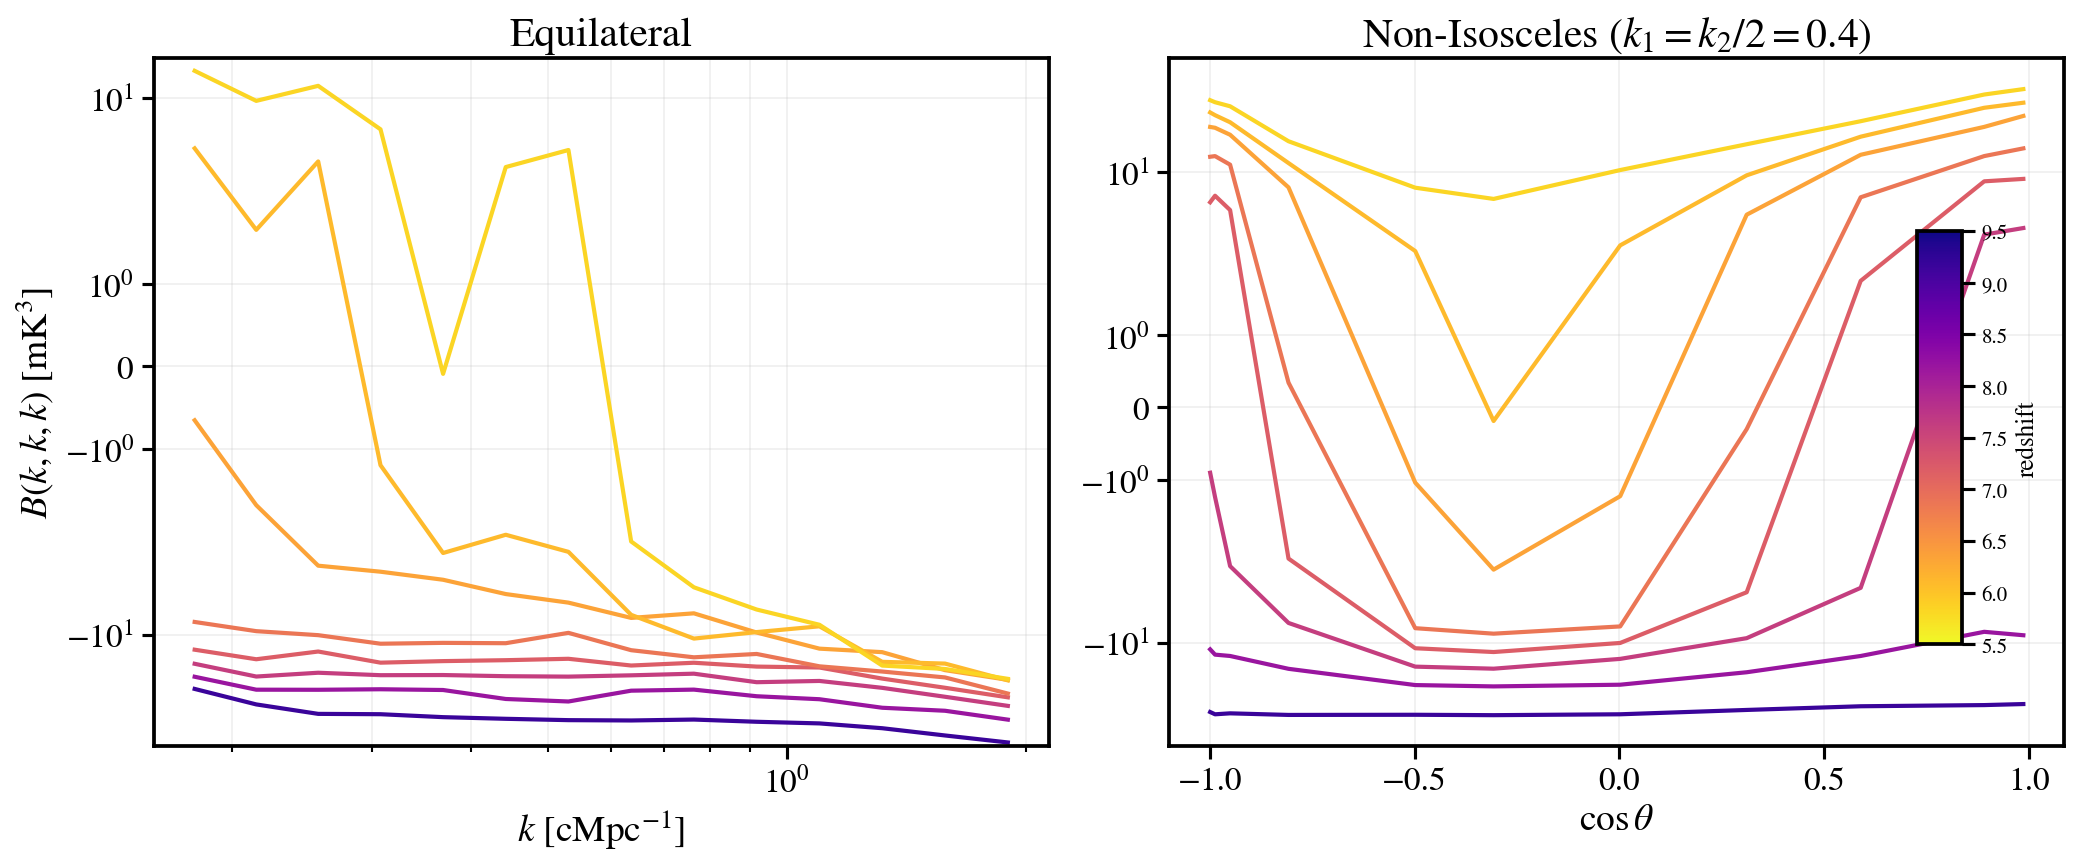

In [9]:
# =====================================
# Configuration
# =====================================
#z_map = {
    #156: 10.0, 181: 9.0, 209: 8.0, 255: 7.0, 
    #289: 6.5, 325: 6.0, 364: 5.5, 406: 5.0
#}
#snaps = [156, 181, 209, 255, 289, 325, 364, 406]

snaps = [177, 203, 220, 242, 264, 300, 318, 338] #[177, 203, 220, 242, 264, 283, 300, 318, 338]
z_map = {
    177: 9.17, 203: 8.20, 220: 7.62, 242: 7.20, 
    264: 6.87, 283: 6.59, 300: 6.34, 318: 6.10,
    338: 5.83
}

base = "/orcd/data/mvogelsb/004/chcho/PS_21cm/bispec"

mode = "f_HII" #Tb "f_HII"

# =====================================
# Colormap (shared)
# =====================================
cmap = plt.cm.plasma_r
norm = mpl.colors.Normalize(vmin=5.5, vmax=9.5)

# =====================================
# Create subplots
# =====================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# LEFT PANEL: Equilateral
# ============================================================
ax = axes[0]

for snap in snaps:
    file = f"{base}/bispec_equi_{snap}_{mode}.txt"

    if not os.path.exists(file):
        continue

    data = np.loadtxt(file)
    if data.size == 0:
        continue

    data = np.atleast_2d(data)

    k = data[:, 1]
    B = data[:, 2]

    idx = np.argsort(k)
    k_sorted = k[idx]
    B_sorted = B[idx]

    z = z_map[snap]
    color = cmap(norm(z))

    ax.plot(k_sorted, B_sorted, color=color, linewidth=2)

rho_file = f"{base}/bispec_equi_264_rho_DM.txt"
data = np.loadtxt(rho_file)

k = data[:, 1]
B  = data[:, 2]

idx = np.argsort(k)

z = z_map[snap]
color = cmap(norm(z))

k_sorted = k[idx]
B_sorted = B[idx]

z = z_map[snap]
color = cmap(norm(z))

#ax.plot(k_sorted, B_sorted, "--", linewidth=2, color="black")
#cos_theta = np.clip(cos_theta, -1.0, 1.0)
#idx = np.argsort(cos_theta)
#ax.plot(cos_theta[idx], B[idx], "--", linewidth=2, color="black")

ax.set_xscale('log')
ax.set_yscale("symlog")
ax.set_xlabel(r"$k \ [\mathrm{cMpc}^{-1}]$", fontsize=18)
ax.set_ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$", fontsize=18)
ax.set_title("Equilateral", fontsize=20)
ax.grid(True, which="both", alpha=0.2)

# ============================================================
# RIGHT PANEL: Non-Isosceles
# ============================================================
ax = axes[1]

for snap in snaps:
    file = f"{base}/bispec_non_iso_{snap}_0.4_0.8_{mode}.txt"

    if not os.path.exists(file):
        continue

    data = np.loadtxt(file)

    k1 = 0.4
    k2 = 0.8
    k3 = data[:, 0]
    B  = data[:, 1]

    cos_theta = (k3**2 - k1**2 - k2**2) / (2 * k1 * k2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.arccos(cos_theta)
    theta_over_pi = theta / np.pi

    idx = np.argsort(theta_over_pi)

    z = z_map[snap]
    color = cmap(norm(z))
    
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    idx = np.argsort(cos_theta)
    ax.plot(cos_theta[idx], B[idx], color=color, linewidth=2)

rho_file = f"{base}/bispec_iso_264_{k1}_rho_DM.txt"
data = np.loadtxt(rho_file)

k3 = data[:, 0]
B  = data[:, 1]

cos_theta = (k3**2 - k1**2 - k2**2) / (2 * k1 * k2)
cos_theta = np.clip(cos_theta, -1.0, 1.0)

theta = np.arccos(cos_theta)
theta_over_pi = theta / np.pi

idx = np.argsort(theta_over_pi)

z = z_map[snap]
color = cmap(norm(z))

cos_theta = np.clip(cos_theta, -1.0, 1.0)
idx = np.argsort(cos_theta)
#ax.plot(cos_theta[idx], B[idx], "--", linewidth=2, color="black")

ax.set_yscale("symlog")
#ax.set_xlabel(r"$\theta / \pi$")
ax.set_xlabel(r"$\cos \theta$", fontsize=18)
#ax.set_ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$")
ax.set_title(f"Non-Isosceles ($k_1 = k_2/2 = 0.4$)", fontsize=20)
ax.grid(alpha=0.2)

# =====================================
# Embedded colorbar (bottom-right panel)
# =====================================
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

ax_cb = axes[-1]

cax = inset_axes(
    ax_cb,
    width="5%",
    height="60%",
    loc="lower right",
    borderpad=3.5
)

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"redshift", fontsize=12)
cbar.ax.tick_params(labelsize=10)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=16)
# =====================================
# Final layout
# =====================================
fig.subplots_adjust(right=0.88)

plt.tight_layout(rect=[0, 0, 0.88, 1])

#plt.savefig("bispec_Tb_frac.png", dpi=300)

plt.show()


## Isosceles Bispectrum

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

z_map = {
    156: 10.0,
    181: 9.0,
    209: 8.0,
    255: 7.0,
    289: 6.5,
    325: 6.0,
    364: 5.5,
    406: 5.0
}

snaps = [156, 181, 209, 255, 289, 325, 364, 406]

k1 = 0.2
k2 = 0.2

plt.figure(figsize=(8,6))

# =====================================
# Colormap setup (THIS is the key change)
# =====================================
cmap = plt.cm.plasma   # similar to your example
norm = mpl.colors.Normalize(vmin=5.0, vmax=10.0)

for snap in snaps:

    file = f"bispec_isosceles_{snap}_TSTK.txt"

    data = np.loadtxt(file)

    k3 = data[:, 0]
    B  = data[:, 1]

    cos_theta = (k3**2 - k1**2 - k2**2) / (2 * k1 * k2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.arccos(cos_theta)
    theta_over_pi = theta / np.pi

    idx = np.argsort(theta_over_pi)

    z = z_map[snap]

    # =====================================
    # Color from colormap (instead of legend)
    # =====================================
    color = cmap(norm(z))

    plt.plot(theta_over_pi[idx], B[idx], marker="o", color=color)

# =====================================
# Colorbar (replace legend)
# =====================================
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Redshift")

# =====================================
# Formatting (unchanged)
# =====================================
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Bispectrum")
plt.title(r"Isosceles Bispectrum Evolution ($k_1 = k_2 = 0.2$)")
plt.grid(alpha=0.3)

# REMOVE legend
# plt.legend()

plt.tight_layout()
plt.show()

FileNotFoundError: bispec_isosceles_156_TSTK.txt not found.

<Figure size 1200x900 with 0 Axes>

## Isosceles Bispectrum (Helium): temp, the actual one is in the other folder


In [13]:
# =====================================
# Configuration (HELIUM)
# =====================================
snaps = [181, 209, 255, 325, 406, 501, 582, 705]
BOX_LEN = 500.0
base_path = "/orcd/data/mvogelsb/005/mkilab001/mvogelsblab003/Lab/Thesan-XL/Flagship_new/postprocessing/ren_640/HeII_VolumeFraction"
#"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/He/Tb"

#k1 = 0.2
k1s = [0.14, 0.2, 0.4, 0.8]
for k1 in k1s:
# =====================================
# Loop over snapshots
# =====================================
    for snap in snaps:
        file_path = f"{base_path}/HeII_VolumeFraction_{snap:03d}.hdf5"
        
    
        if not os.path.exists(file_path):
            print(f"[SKIP] {file_path}")
            continue
    
        print(f"\n=== Snapshot {snap} ===")
    
        with h5py.File(file_path, 'r') as f:
            dT_box = np.array(f["HeII_VolumeFraction"][:]) # rin
        
        BOX_DIM = dT_box.shape[0]
    
        # ---------------------------------
        # Run bispectrum
        # ---------------------------------
        BS_iso = bifft.calculate_isoc_bipec(
            data=dT_box,
            DIM=[BOX_DIM],
            LEN=[BOX_LEN],
            k_1=k1,
            normalise=True
        )
    
        # ---------------------------------
        # Save output
        # ---------------------------------
        out_file = f"He_bispec_iso_{snap}_{k1}_f_HII.txt"
    
        with open(out_file, "w") as f:
            for i in range(len(BS_iso["k3"])):
                f.write(
                    "{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n".format(
                        BS_iso["k3"][i],
                        BS_iso["BS"][i],
                        BS_iso["BSimag"][i],
                        BS_iso["k1"][i],
                        BS_iso["k2"][i],
                        BS_iso["P1"][i],
                        BS_iso["P2"][i],
                        BS_iso["P3"][i],
                        BS_iso["Ntri"][i],
                        i
                    )
                )
    
        # ---------------------------------
        # Quick check
        # ---------------------------------
        print("Saved:", out_file)
        print("k3 sample:", BS_iso["k3"][:3])
        print("BS sample:", BS_iso["BS"][:3])
    
        # Optional: free memory
        del dT_box, BS_iso


=== Snapshot 181 ===



KeyboardInterrupt



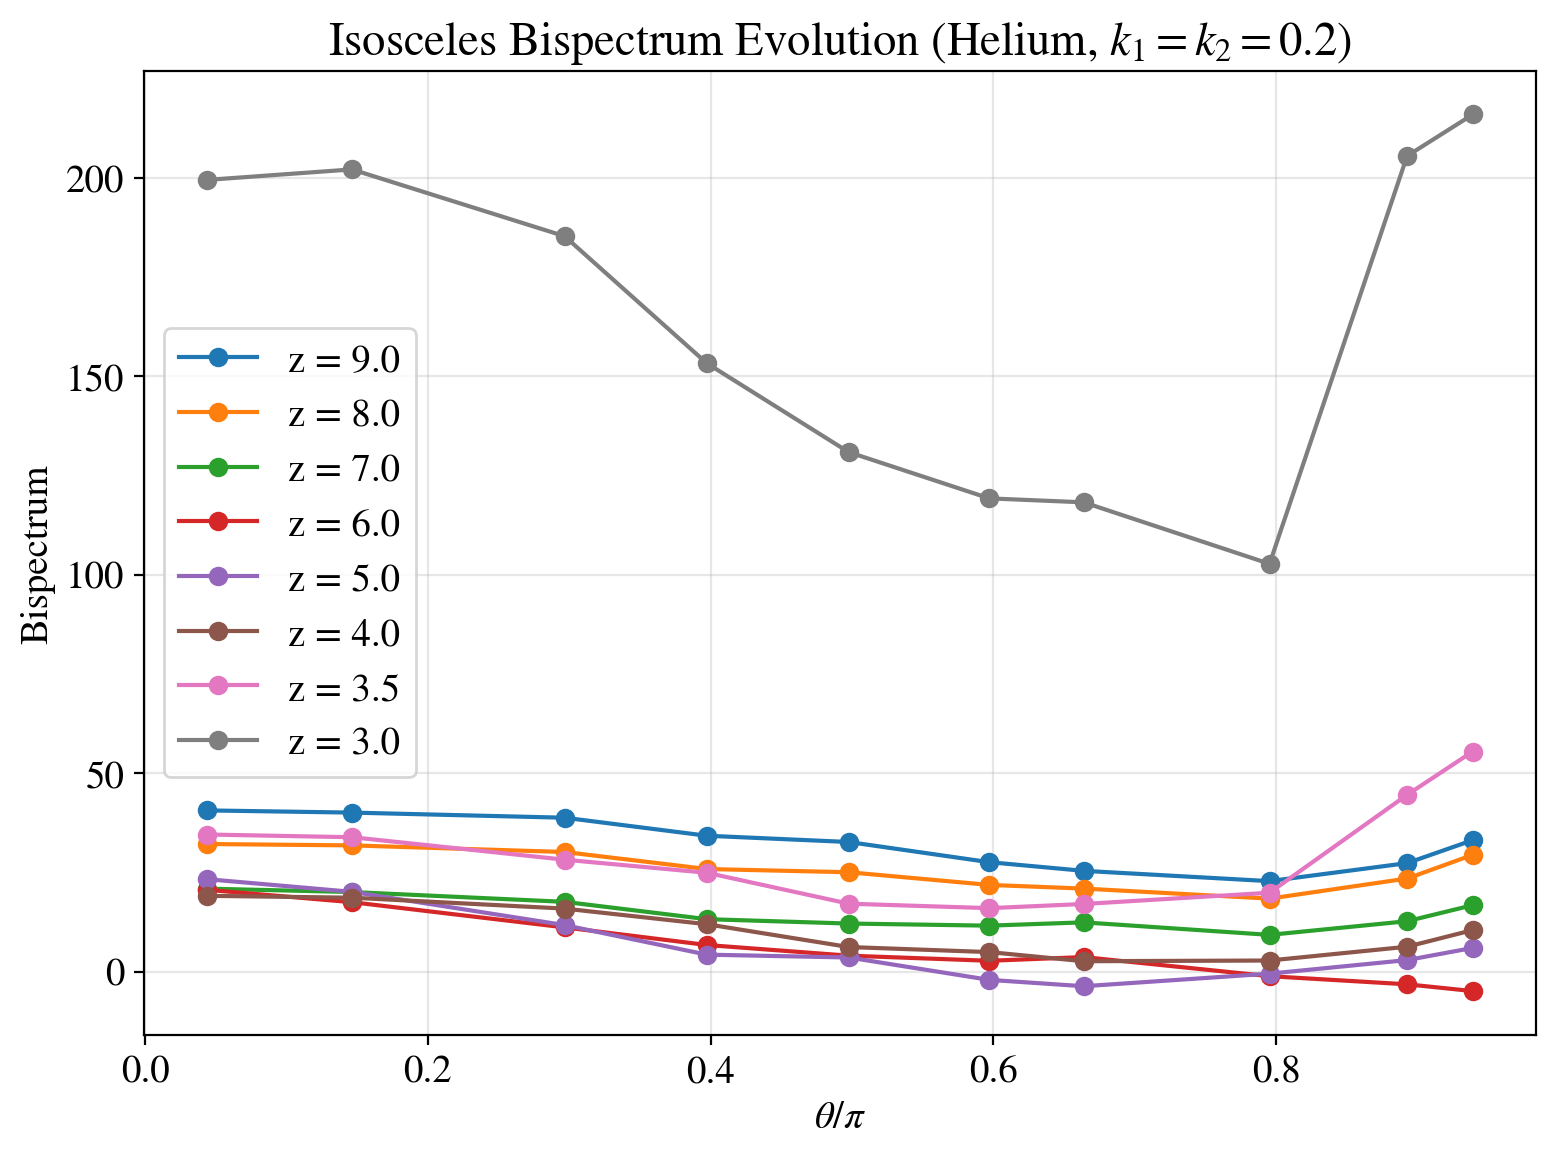

In [6]:
# =====================================
# Configuration & Mapping
# =====================================
z_map = {
    181: 9.0, 209: 8.0, 255: 7.0, 325: 6.0, 
    406: 5.0, 501: 4.0, 582: 3.5, 705: 3.0
}

snaps = [181, 209, 255, 325, 406, 501, 582, 705] #

k1 = 0.2
k2 = 0.2

plt.figure(figsize=(8,6))

for snap in snaps:

    file = f"He_bispec_iso_{snap}_f_HII.txt"

    # ---------------------------------
    # Load data
    # ---------------------------------
    data = np.loadtxt(file)

    k3 = data[:, 0]
    B  = data[:, 1]

    # ---------------------------------
    # Compute theta/pi
    # ---------------------------------
    cos_theta = (k3**2 - k1**2 - k2**2) / (2 * k1 * k2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.arccos(cos_theta)
    theta_over_pi = theta / np.pi

    # Sort (important for clean lines)
    idx = np.argsort(theta_over_pi)

    # ---------------------------------
    # Plot
    # ---------------------------------
    z = z_map[snap]
    plt.plot(theta_over_pi[idx], B[idx], marker="o", label=f"z = {z}")

# =====================================
# Formatting
# =====================================
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Bispectrum")
plt.title(r"Isosceles Bispectrum Evolution (Helium, $k_1 = k_2 = 0.2$)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Isosceles (THESAN-1 Hydrogen)

In [9]:
# =====================================
# Snapshot list
# =====================================
snaps = [105, 139, 182, 240, 318, 369]

base_path = "/orcd/data/mvogelsb/004/chcho/PS_21cm/past/original/Thesan-1"

BOX_LEN = 95.5

k1 = 0.2
k2 = 0.2

z_map = {
    105: 10.0,
    139: 9.0,
    182: 8.0,
    240: 7.0,
    318: 6.0,
    369: 5.5
}


# =====================================
# Loop over snapshots
# =====================================
for snap in snaps:

    file_path = f"{base_path}/H_Tb_{snap:03d}.hdf5"

    if not os.path.exists(file_path):
        print(f"[SKIP] File not found: {file_path}")
        continue

    print(f"\n=== Processing snapshot {snap} ===")

    # ---------------------------------
    # Load data
    # ---------------------------------
    with h5py.File(file_path, 'r') as f:
        dT_box = f["Tb"][:]

    BOX_DIM = dT_box.shape[0]

    # ---------------------------------
    # Run bispectrum
    # ---------------------------------
    BS_iso = bifft.calculate_isoc_bipec(
        data=dT_box,
        DIM=[BOX_DIM],
        LEN=[BOX_LEN],
        k_1=k1,
        normalise=True
    )

    # ---------------------------------
    # Save output
    # ---------------------------------
    out_file = f"bispec_isosceles_{snap}_THESAN-1.txt"

    with open(out_file, "w") as f:
        for i in range(len(BS_iso["k3"])):
            f.write(
                "{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n".format(
                    BS_iso["k3"][i],
                    BS_iso["BS"][i],
                    BS_iso["BSimag"][i],
                    BS_iso["k1"][i],
                    BS_iso["k2"][i],
                    BS_iso["P1"][i],
                    BS_iso["P2"][i],
                    BS_iso["P3"][i],
                    BS_iso["Ntri"][i],
                    i
                )
            )

    # ---------------------------------
    # Quick check
    # ---------------------------------
    print("Saved:", out_file)
    print("k3 sample:", BS_iso["k3"][:3])
    print("BS sample:", BS_iso["BS"][:3])

    # Optional: free memory
    del dT_box, BS_iso


=== Processing snapshot 105 ===
Saved: bispec_isosceles_105_THESAN-1.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [-7.23382218 -5.77331931 -3.99312549]

=== Processing snapshot 139 ===
Saved: bispec_isosceles_139_THESAN-1.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [-10.69321512 -10.24415992 -10.57612988]

=== Processing snapshot 182 ===
Saved: bispec_isosceles_182_THESAN-1.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [-20.96068117 -21.31828171 -21.01225565]

=== Processing snapshot 240 ===
Saved: bispec_isosceles_240_THESAN-1.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [-6.34988557 -4.78644037 -3.13997619]

=== Processing snapshot 318 ===
Saved: bispec_isosceles_318_THESAN-1.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [23.97702366 19.68121261 15.7103709 ]

=== Processing snapshot 369 ===
Saved: bispec_isosceles_369_THESAN-1.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [87.1384396  87.08

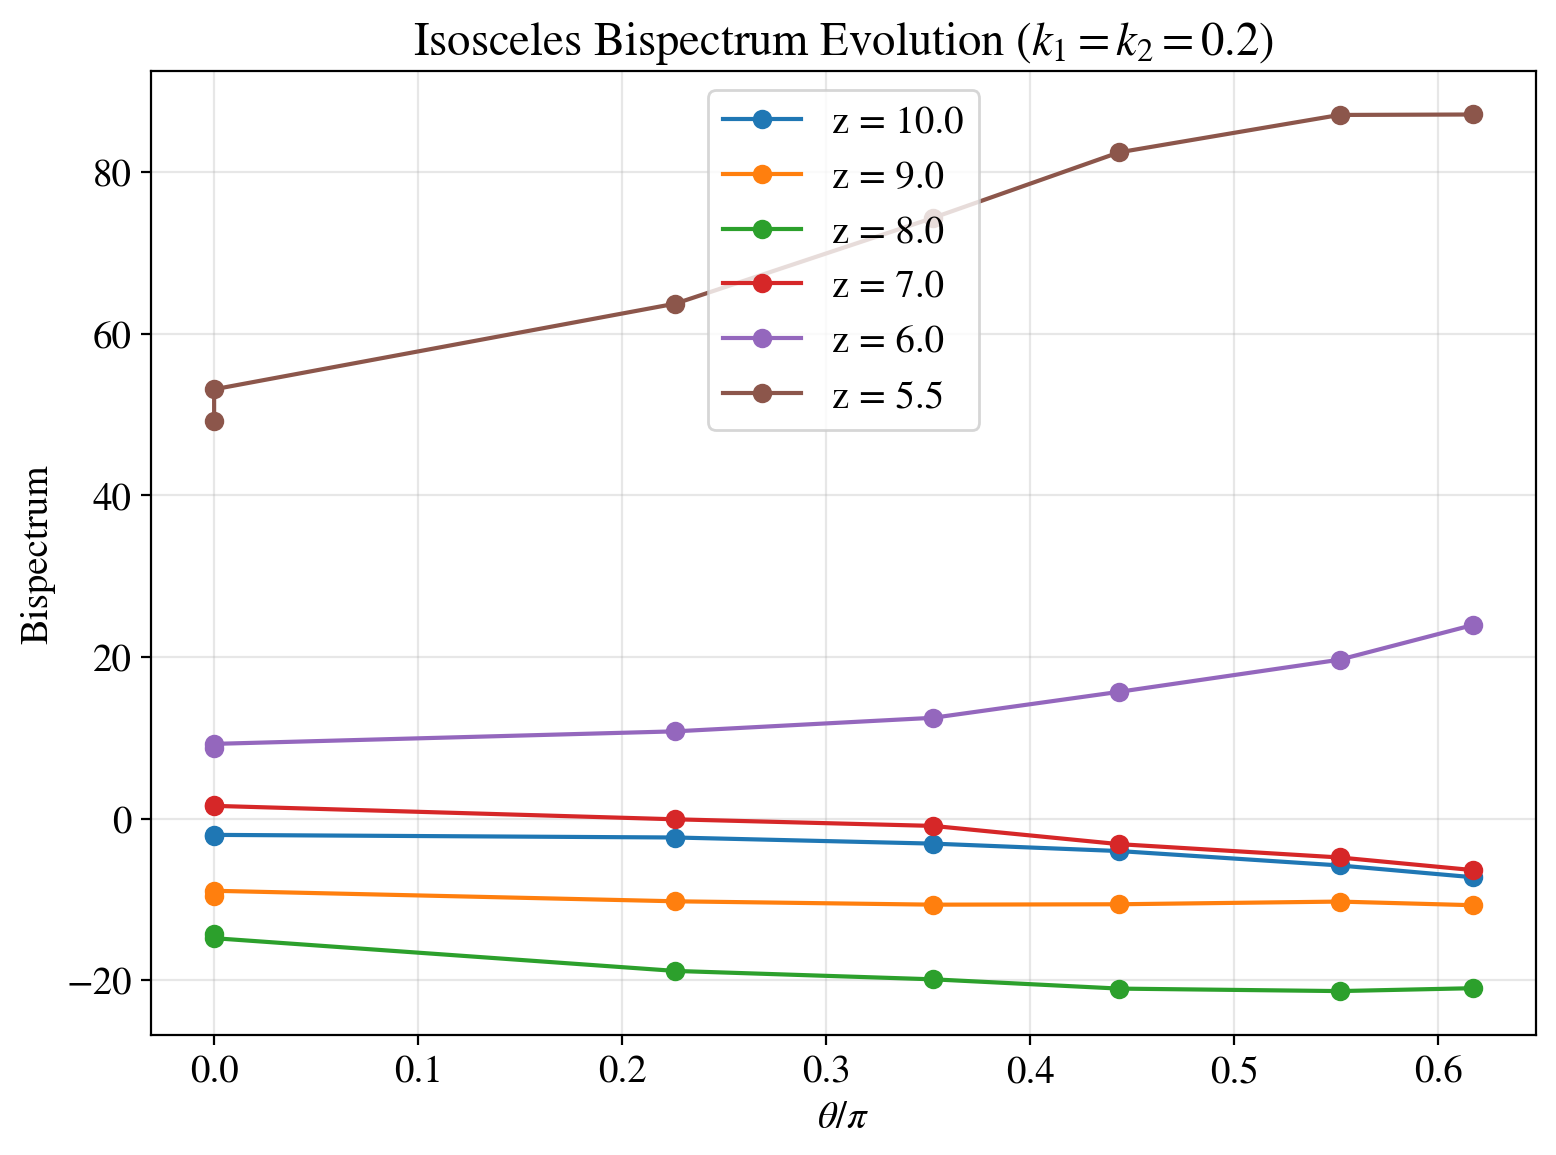

In [10]:

plt.figure(figsize=(8,6))

for snap in snaps:

    file = f"bispec_isosceles_{snap}_THESAN-1.txt"

    # ---------------------------------
    # Load data
    # ---------------------------------
    data = np.loadtxt(file)

    k3 = data[:, 0]
    B  = data[:, 1]

    # ---------------------------------
    # Compute theta/pi
    # ---------------------------------
    cos_theta = (k3**2 - k1**2 - k2**2) / (2 * k1 * k2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.arccos(cos_theta)
    theta_over_pi = theta / np.pi

    # Sort (important for clean lines)
    idx = np.argsort(theta_over_pi)

    # ---------------------------------
    # Plot
    # ---------------------------------
    z = z_map[snap]
    plt.plot(theta_over_pi[idx], B[idx], marker="o", label=f"z = {z}")

# =====================================
# Formatting
# =====================================
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Bispectrum")
plt.title(r"Isosceles Bispectrum Evolution ($k_1 = k_2 = 0.2$)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Isosceles (THESAN-2 Hydrogen)

In [11]:
# =====================================
# Snapshot list
# =====================================
snaps = [136, 170, 213, 271, 349, 400]

base_path = "/orcd/data/mvogelsb/004/chcho/PS_21cm/past/original/Thesan-2"

BOX_LEN = 95.5

k1 = 0.2
k2 = 0.2

z_map = {
    136: 10.0,
    170: 9.0,
    213: 8.0,
    271: 7.0,
    349: 6.0,
    400: 5.5
}


# =====================================
# Loop over snapshots
# =====================================
for snap in snaps:

    file_path = f"{base_path}/H_Tb_{snap:03d}.hdf5"

    if not os.path.exists(file_path):
        print(f"[SKIP] File not found: {file_path}")
        continue

    print(f"\n=== Processing snapshot {snap} ===")

    # ---------------------------------
    # Load data
    # ---------------------------------
    with h5py.File(file_path, 'r') as f:
        dT_box = f["Tb"][:]

    BOX_DIM = dT_box.shape[0]

    # ---------------------------------
    # Run bispectrum
    # ---------------------------------
    BS_iso = bifft.calculate_isoc_bipec(
        data=dT_box,
        DIM=[BOX_DIM],
        LEN=[BOX_LEN],
        k_1=k1,
        normalise=True
    )

    # ---------------------------------
    # Save output
    # ---------------------------------
    out_file = f"bispec_isosceles_{snap}_THESAN-2.txt"

    with open(out_file, "w") as f:
        for i in range(len(BS_iso["k3"])):
            f.write(
                "{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n".format(
                    BS_iso["k3"][i],
                    BS_iso["BS"][i],
                    BS_iso["BSimag"][i],
                    BS_iso["k1"][i],
                    BS_iso["k2"][i],
                    BS_iso["P1"][i],
                    BS_iso["P2"][i],
                    BS_iso["P3"][i],
                    BS_iso["Ntri"][i],
                    i
                )
            )

    # ---------------------------------
    # Quick check
    # ---------------------------------
    print("Saved:", out_file)
    print("k3 sample:", BS_iso["k3"][:3])
    print("BS sample:", BS_iso["BS"][:3])

    # Optional: free memory
    del dT_box, BS_iso


=== Processing snapshot 136 ===
Saved: bispec_isosceles_136_THESAN-2.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [-0.62252713 -0.57837265  0.18808091]

=== Processing snapshot 170 ===
Saved: bispec_isosceles_170_THESAN-2.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [-6.75212195 -4.76205816 -2.7744581 ]

=== Processing snapshot 213 ===
Saved: bispec_isosceles_213_THESAN-2.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [-18.56259556 -18.42734223 -18.45419236]

=== Processing snapshot 271 ===
Saved: bispec_isosceles_271_THESAN-2.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [-12.42740176 -10.90494339  -8.56642508]

=== Processing snapshot 349 ===
Saved: bispec_isosceles_349_THESAN-2.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [18.8340856  15.12859863 13.0918426 ]

=== Processing snapshot 400 ===
Saved: bispec_isosceles_400_THESAN-2.txt
k3 sample: [0.22637412 0.2590172  0.30676727]
BS sample: [80.52004377 74.80

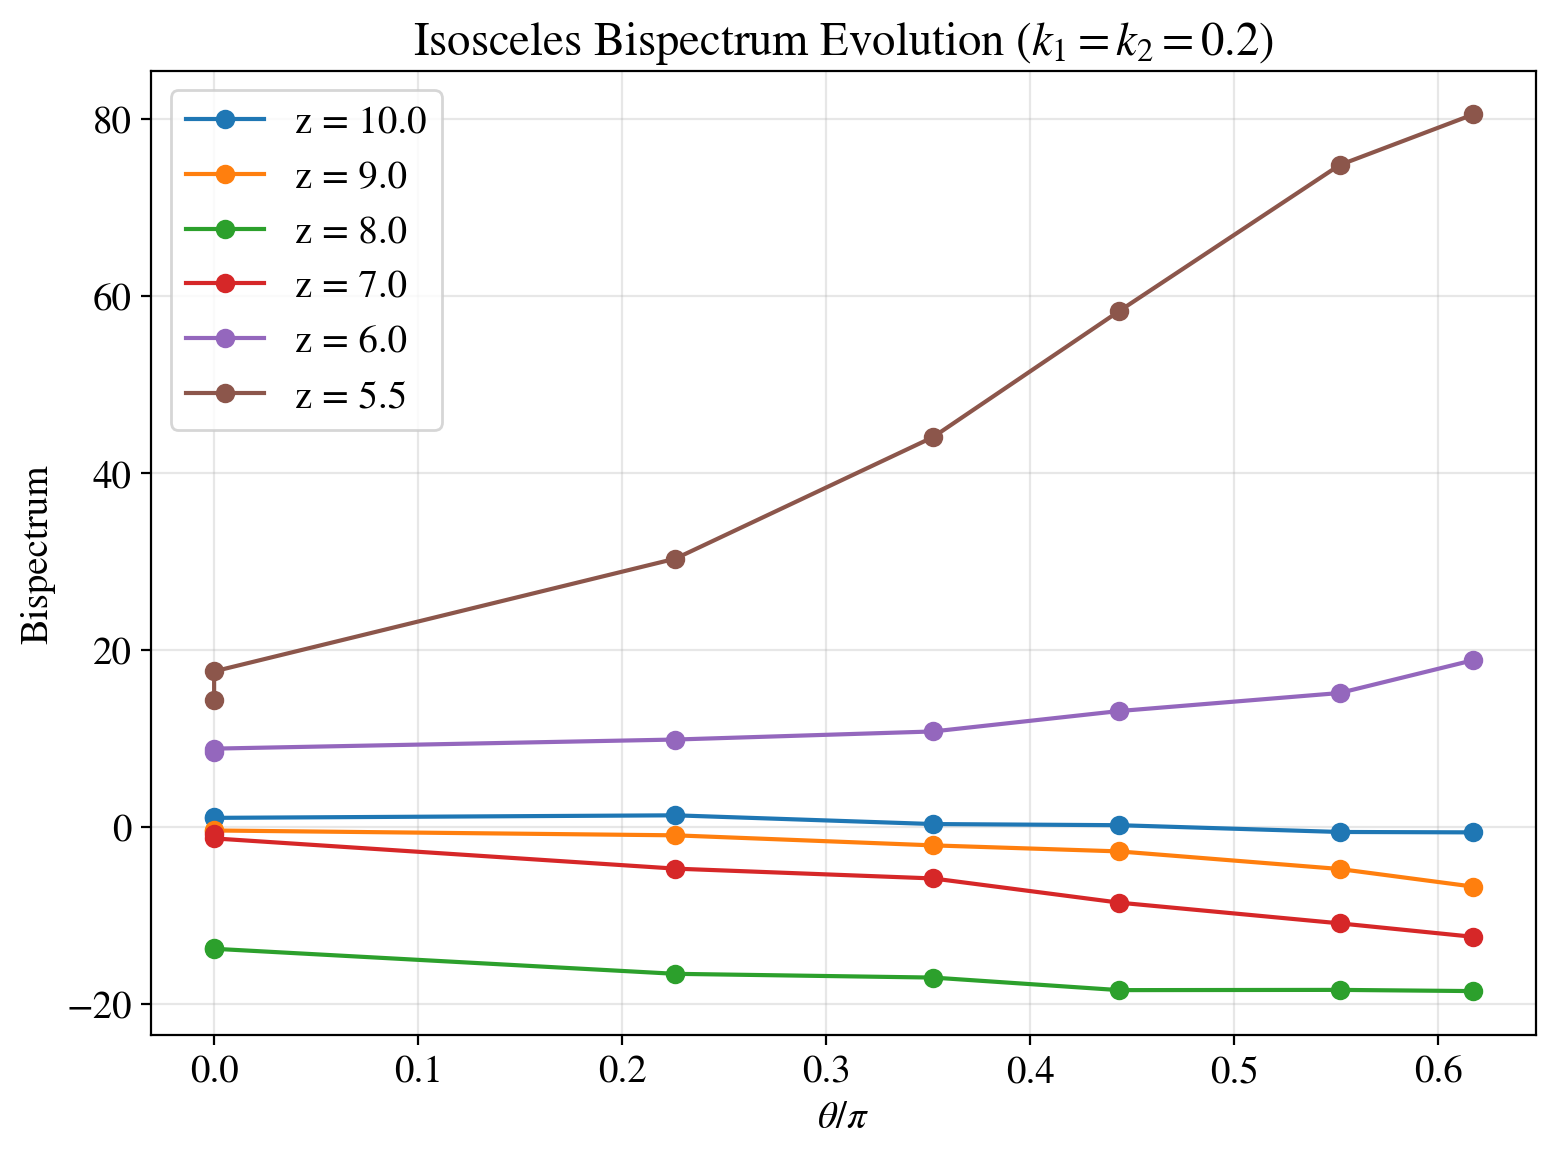

In [12]:

plt.figure(figsize=(8,6))

for snap in snaps:

    file = f"bispec_isosceles_{snap}_THESAN-2.txt"

    # ---------------------------------
    # Load data
    # ---------------------------------
    data = np.loadtxt(file)

    k3 = data[:, 0]
    B  = data[:, 1]

    # ---------------------------------
    # Compute theta/pi
    # ---------------------------------
    cos_theta = (k3**2 - k1**2 - k2**2) / (2 * k1 * k2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.arccos(cos_theta)
    theta_over_pi = theta / np.pi

    # Sort (important for clean lines)
    idx = np.argsort(theta_over_pi)

    # ---------------------------------
    # Plot
    # ---------------------------------
    z = z_map[snap]
    plt.plot(theta_over_pi[idx], B[idx], marker="o", label=f"z = {z}")

# =====================================
# Formatting
# =====================================
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Bispectrum")
plt.title(r"Isosceles Bispectrum Evolution ($k_1 = k_2 = 0.2$)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Equilateral Bispectrum

In [1]:
import os
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d
from scipy.integrate import quad
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['agg.path.chunksize'] = 10000

# Set universal font properties
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})

import bifft
import pickle
np.complex = complex

# =====================================
# Configuration
# =====================================
snaps = [406] #209, 255, 289, 325, 364, 406] #156, 181, 
base_path = "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb"
BOX_LEN = 500.0

# Wavenumber range of interest
k_min, k_max = 0.15, 2.0

# =====================================
# Loop over snapshots
# =====================================
for snap in snaps:
    file_path = f"{base_path}/Tb_H_{snap:03d}.hdf5"

    if not os.path.exists(file_path):
        print(f"[SKIP] {file_path}")
        continue

    print(f"\n=== Snapshot {snap} ===")

    with h5py.File(file_path, 'r') as f:
        dT_box = np.array(f["rin"][:])

    BOX_DIM = dT_box.shape[0]

    # Calculate exactly as the example does
    BS_equi_dict = bifft.calculate_equi_bipec(
        data=dT_box, 
        DIM=[BOX_DIM], 
        LEN=[BOX_LEN], 
        K_FAC=1.1,
        normalise=True
    )

    # Filter based on k3 (the primary k-scale for equilateral) within your range
    k3_vals = np.array(BS_equi_dict["k3"])
    mask = (k3_vals >= k_min) & (k3_vals <= k_max)

    # =====================================
    # Save all columns from the example
    # =====================================
    out_file = f"bispec_equi_{snap}_Tb.txt"
    
    header = ("theta_over_pi\tk3\tBS_real\tBS_imag\tk1\tk2\tP1\tP2\tP3\tNtri")
    
    # We stack all the keys mentioned in your assert statements
    data_to_save = np.column_stack((
        np.array(BS_equi_dict["theta_over_pi"])[mask],
        np.array(BS_equi_dict["k3"])[mask],
        np.array(BS_equi_dict["BS"])[mask],
        np.array(BS_equi_dict["BSimag"])[mask],
        np.array(BS_equi_dict["k1"])[mask],
        np.array(BS_equi_dict["k2"])[mask],
        np.array(BS_equi_dict["P1"])[mask],
        np.array(BS_equi_dict["P2"])[mask],
        np.array(BS_equi_dict["P3"])[mask],
        np.array(BS_equi_dict["Ntri"])[mask]
    ))

    np.savetxt(out_file, data_to_save, header=header, fmt='%.6e', delimiter='\t')

    print(f"Saved complete dictionary data to: {out_file}")
    del dT_box

Initiating args for bispec code...

=== Snapshot 406 ===


 bispec.cc::equi_bispec -> kmax = 4.02


Saved complete dictionary data to: bispec_equi_406_Tb.txt


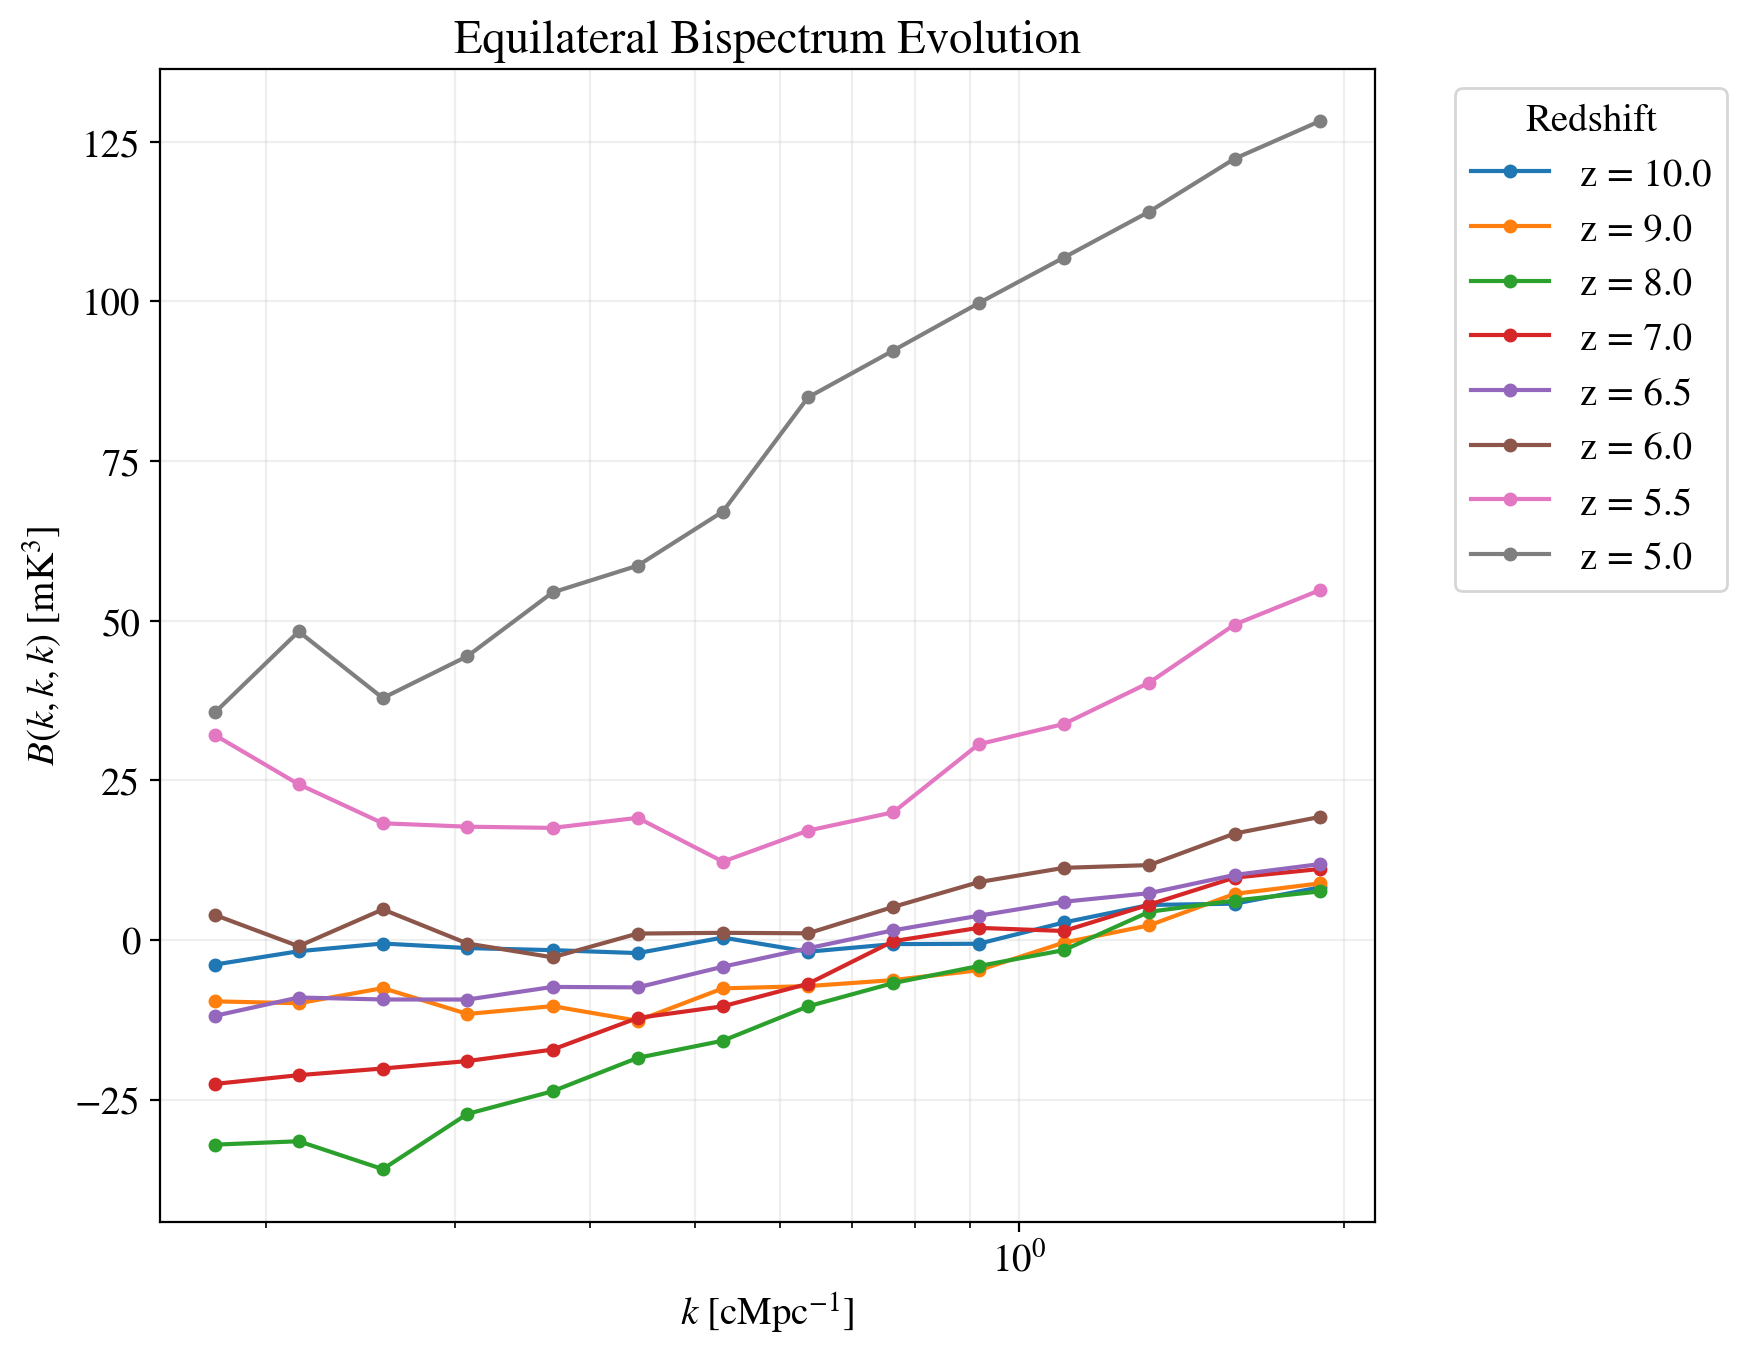

In [6]:
# =====================================
# Configuration & Mapping
# =====================================
z_map = {
    156: 10.0, 181: 9.0, 209: 8.0, 255: 7.0, 
    289: 6.5, 325: 6.0, 364: 5.5, 406: 5.0
}

snaps = [156, 181, 209, 255, 289, 325, 364, 406]

plt.figure(figsize=(9, 7))

for snap in snaps:
    # Pointing to the "full" filename created in the previous step
    file = f"bispec_equilateral_full_{snap}.txt"

    if not os.path.exists(file):
        print(f"[SKIP] {file}")
        continue

    # Load the 10-column data
    data = np.loadtxt(file)
    if data.size == 0:
        continue
    
    data = np.atleast_2d(data)

    # UPDATED INDICES for the 10-column output:
    # Column 0: theta_over_pi
    # Column 1: k3 (this is your k)
    # Column 2: BS (this is your B)
    k = data[:, 1]
    B = data[:, 2]

    # Sort by k to ensure lines connect correctly
    idx = np.argsort(k)
    k_sorted = k[idx]
    B_sorted = B[idx]

    z = z_map[snap]

    # Plotting absolute value of B as it can sometimes be negative 
    # depending on the physics/fluctuations
    plt.plot(k_sorted, B_sorted, marker="o", markersize=4, label=f"z = {z}")

# =====================================
# Formatting for Cosmology
# =====================================
plt.xscale('log')
#plt.yscale('log') # Bispectra usually span several orders of magnitude

plt.xlabel(r"$k \ [\mathrm{cMpc}^{-1}]$")
plt.ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$") # \ cMpc^6
plt.title("Equilateral Bispectrum Evolution")

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Redshift", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Optional: Save the plot
# plt.savefig("equilateral_bispectrum_plot.png", dpi=300)
plt.show()

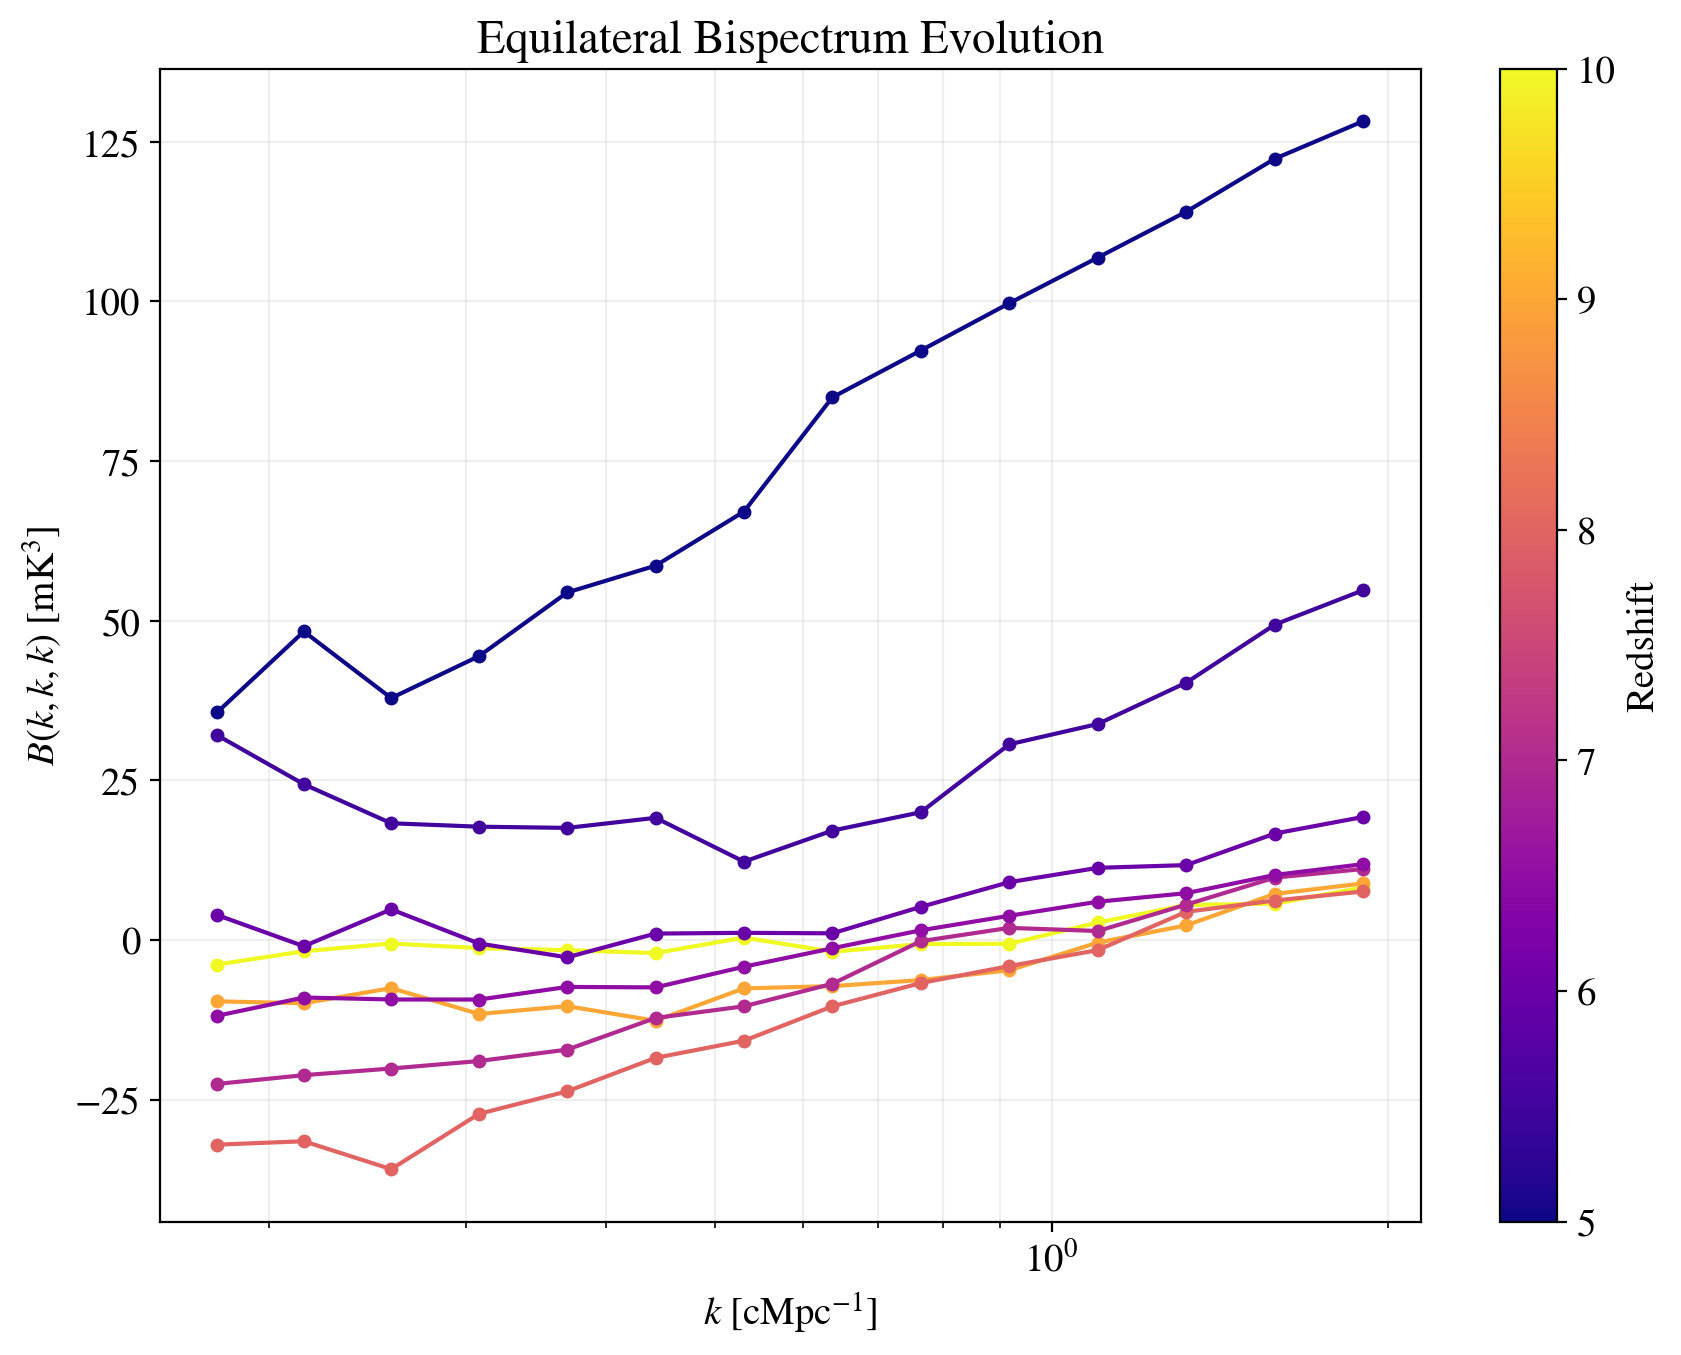

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

# =====================================
# Configuration & Mapping
# =====================================
z_map = {
    156: 10.0, 181: 9.0, 209: 8.0, 255: 7.0, 
    289: 6.5, 325: 6.0, 364: 5.5, 406: 5.0
}

snaps = [156, 181, 209, 255, 289, 325, 364, 406]

plt.figure(figsize=(9, 7))

# =====================================
# Colormap setup
# =====================================
cmap = plt.cm.plasma
norm = mpl.colors.Normalize(vmin=5.0, vmax=10.0)

for snap in snaps:

    file = f"bispec_equilateral_full_{snap}.txt"

    if not os.path.exists(file):
        print(f"[SKIP] {file}")
        continue

    data = np.loadtxt(file)
    if data.size == 0:
        continue
    
    data = np.atleast_2d(data)

    k = data[:, 1]
    B = data[:, 2]

    idx = np.argsort(k)
    k_sorted = k[idx]
    B_sorted = B[idx]

    z = z_map[snap]

    # =====================================
    # Use colormap instead of legend
    # =====================================
    color = cmap(norm(z))

    plt.plot(k_sorted, B_sorted, marker="o", markersize=4, color=color)

# =====================================
# Colorbar (FIXED)
# =====================================
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())   # <-- THIS fixes your error
cbar.set_label("Redshift")

# =====================================
# Formatting (unchanged)
# =====================================
plt.xscale('log')

plt.xlabel(r"$k \ [\mathrm{cMpc}^{-1}]$")
plt.ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$")
plt.title("Equilateral Bispectrum Evolution")

plt.grid(True, which="both", ls="-", alpha=0.2)

# REMOVE legend
# plt.legend(...)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1017485/2361010546.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


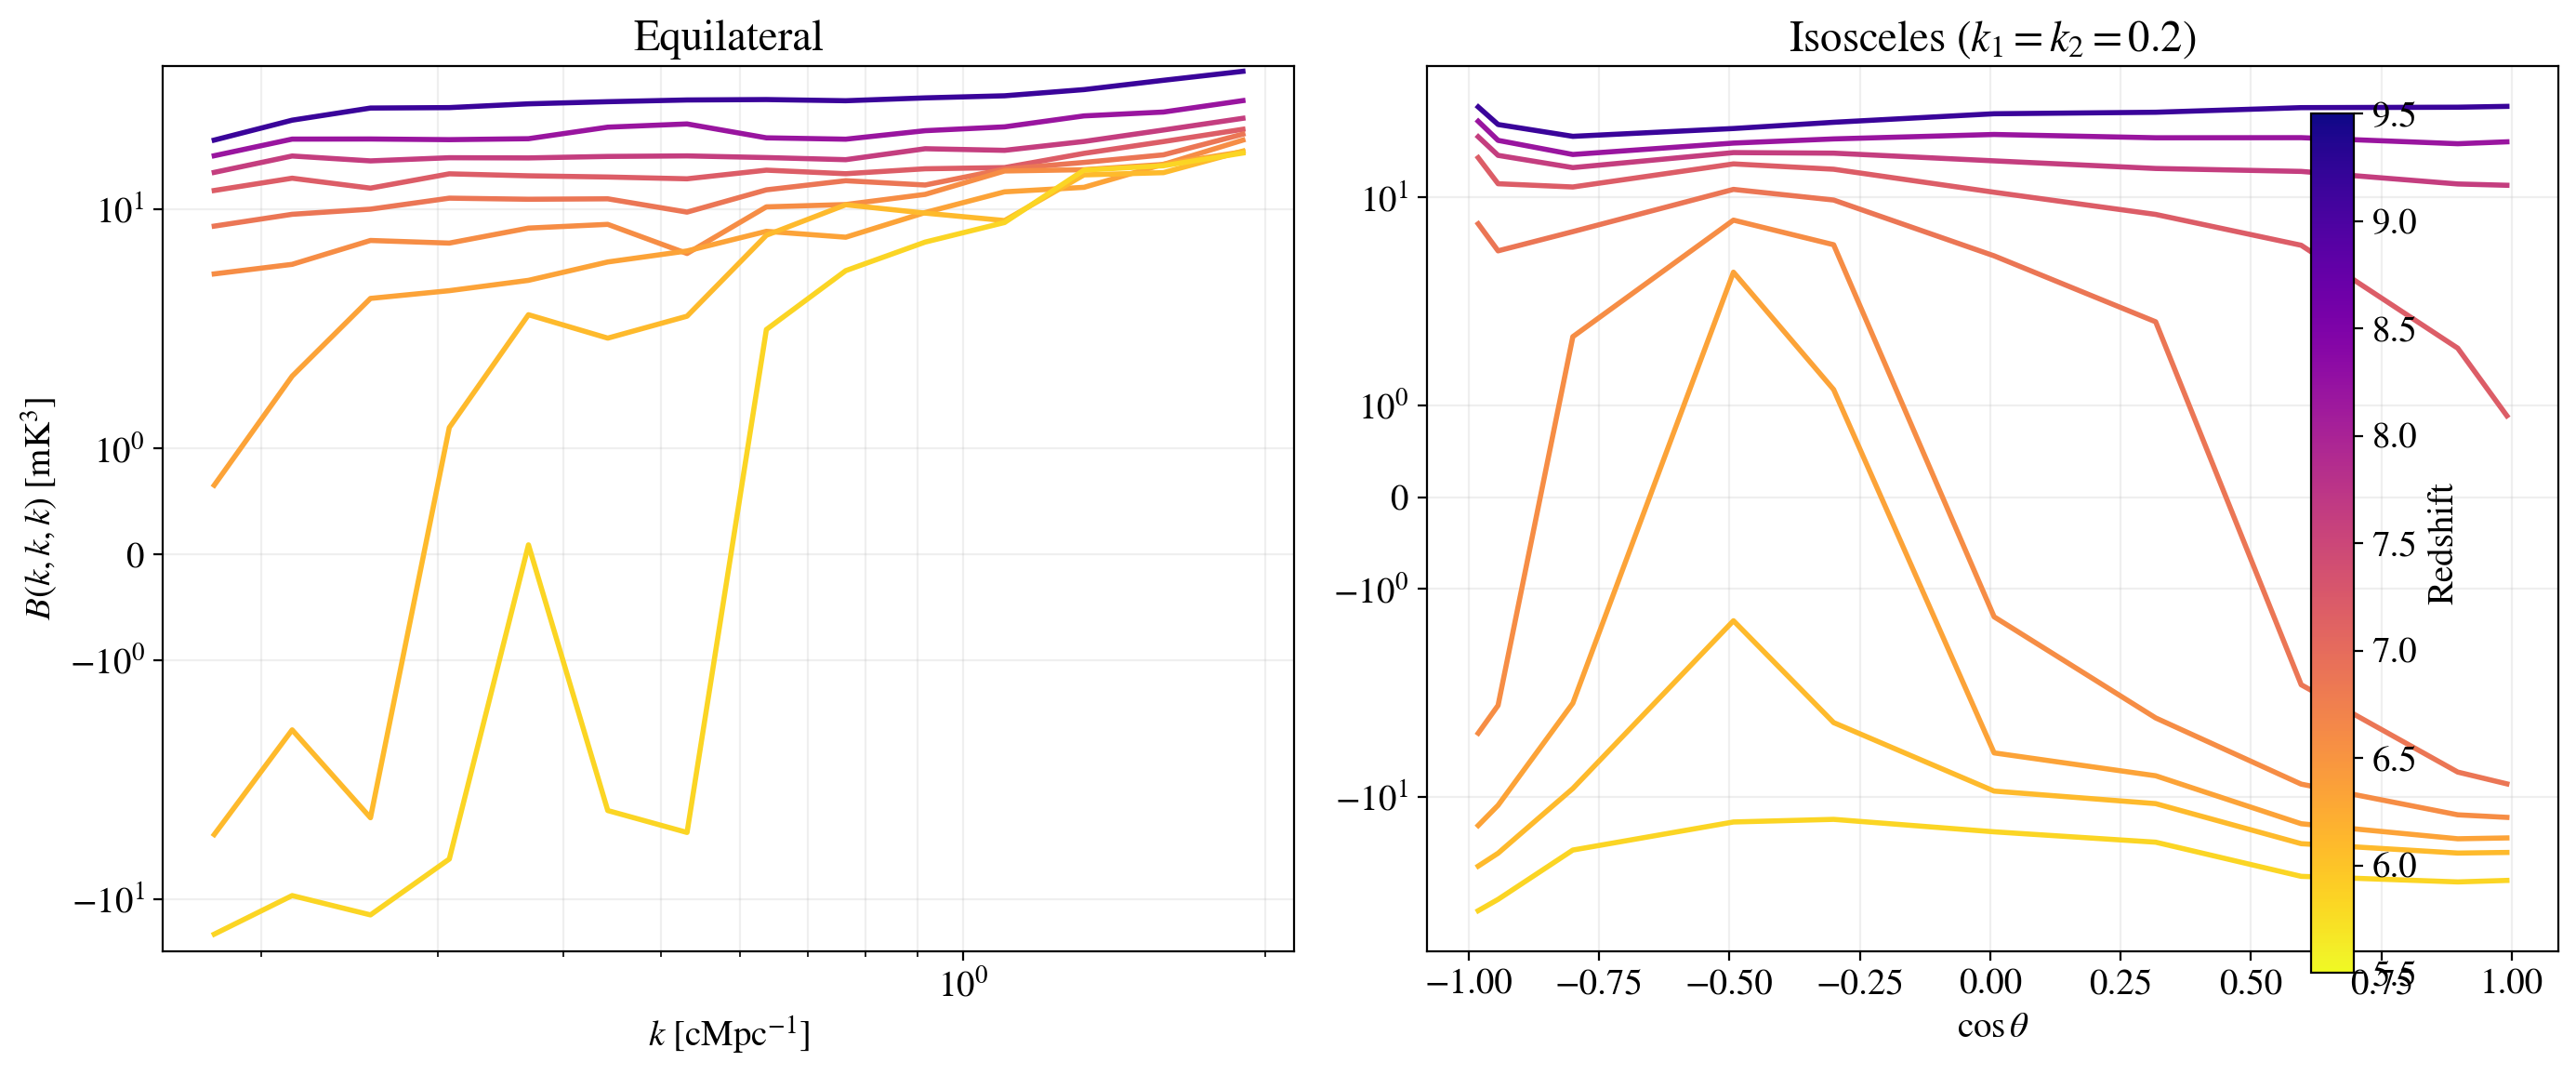

In [28]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

# =====================================
# Configuration
# =====================================
#z_map = {
    #156: 10.0, 181: 9.0, 209: 8.0, 255: 7.0, 
    #289: 6.5, 325: 6.0, 364: 5.5, 406: 5.0
#}
#snaps = [156, 181, 209, 255, 289, 325, 364, 406]

snaps = [177, 203, 220, 242, 264, 283, 300, 318, 338]
z_map = {
    177: 9.17, 203: 8.20, 220: 7.62, 242: 7.20, 
    264: 6.87, 283: 6.59, 300: 6.34, 318: 6.10,
    338: 5.83
}

base = "/orcd/data/mvogelsb/004/chcho/PS_21cm/bispec"



k1 = 0.2
k2 = 0.2

# =====================================
# Colormap (shared)
# =====================================
cmap = plt.cm.plasma_r
norm = mpl.colors.Normalize(vmin=5.5, vmax=9.5)

# =====================================
# Create subplots
# =====================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# LEFT PANEL: Equilateral
# ============================================================
ax = axes[0]

for snap in snaps:
    file = f"{base}/bispec_equilateral_{snap}_f_HII.txt"

    if not os.path.exists(file):
        continue

    data = np.loadtxt(file)
    if data.size == 0:
        continue

    data = np.atleast_2d(data)

    k = data[:, 1]
    B = data[:, 2]

    idx = np.argsort(k)
    k_sorted = k[idx]
    B_sorted = B[idx]

    z = z_map[snap]
    color = cmap(norm(z))

    ax.plot(k_sorted, B_sorted, color=color, linewidth=2)

ax.set_xscale('log')
ax.set_yscale("symlog")
ax.set_xlabel(r"$k \ [\mathrm{cMpc}^{-1}]$")
ax.set_ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$")
ax.set_title("Equilateral")
ax.grid(True, which="both", alpha=0.2)

# ============================================================
# RIGHT PANEL: Isosceles
# ============================================================
ax = axes[1]

for snap in snaps:
    file = f"{base}/bispec_isosceles_{snap}_f_HII.txt"

    if not os.path.exists(file):
        continue

    data = np.loadtxt(file)

    k3 = data[:, 0]
    B  = data[:, 1]

    cos_theta = (k3**2 - k1**2 - k2**2) / (2 * k1 * k2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.arccos(cos_theta)
    theta_over_pi = theta / np.pi

    idx = np.argsort(theta_over_pi)

    z = z_map[snap]
    color = cmap(norm(z))

    

    #ax.plot(theta_over_pi[idx], B[idx], color=color, linewidth=2)

    #if I want cos_theta
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    idx = np.argsort(cos_theta)
    ax.plot(cos_theta[idx], B[idx], color=color, linewidth=2)

ax.set_yscale("symlog")
#ax.set_xlabel(r"$\theta / \pi$")
ax.set_xlabel(r"$\cos \theta$")
#ax.set_ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$")
ax.set_title("Isosceles ($k_1 = k_2 = 0.2$)")
ax.grid(alpha=0.2)

# =====================================
# Shared colorbar
# =====================================
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Place colorbar in that space
cbar = fig.colorbar(sm, ax=axes, location='right', pad=0.02)
cbar.set_label("Redshift")

# =====================================
# Final layout
# =====================================
fig.subplots_adjust(right=0.88)

plt.tight_layout(rect=[0, 0, 0.88, 1])

plt.savefig("bispec_Tb_frac.png", dpi=300)

plt.show()


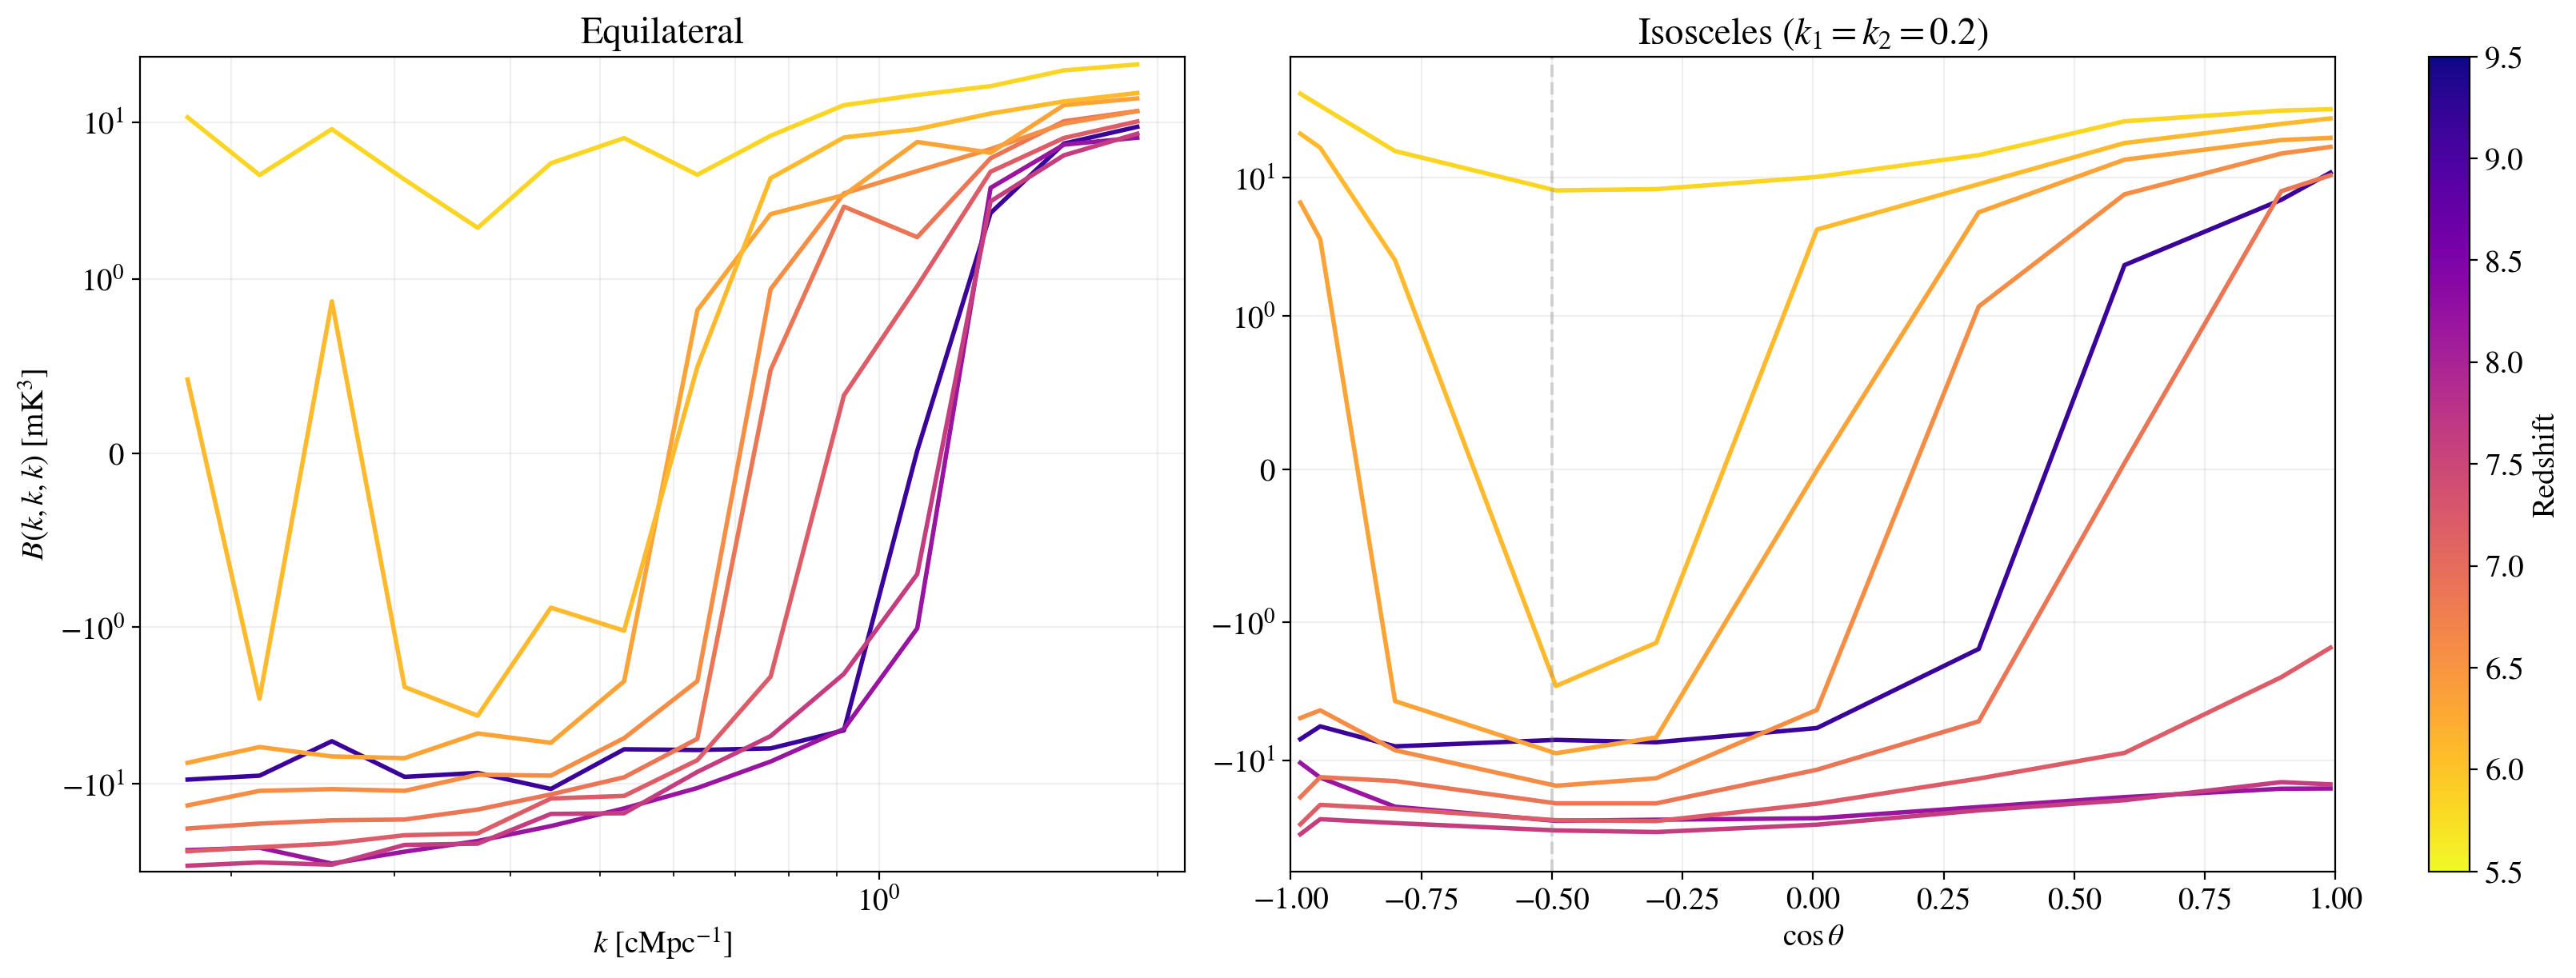

In [45]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

# =====================================
# Configuration
# =====================================
snaps = [177, 203, 220, 242, 264, 283, 300, 318, 338]

z_map = {
    177: 9.17, 203: 8.20, 220: 7.62, 242: 7.20, 
    264: 6.87, 283: 6.59, 300: 6.34, 318: 6.10,
    338: 5.83
}

base = "/orcd/data/mvogelsb/004/chcho/PS_21cm/bispec"

k1 = 0.2
k2 = 0.2

# =====================================
# Colormap
# =====================================
cmap = plt.cm.plasma_r
norm = mpl.colors.Normalize(vmin=5.5, vmax=9.5)

# =====================================
# Figure
# =====================================
#fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# =====================================
# LEFT: Equilateral
# =====================================
ax = axes[0]

for snap in snaps:
    file = f"{base}/bispec_equilateral_{snap}_Tb.txt"

    if not os.path.exists(file):
        continue

    data = np.loadtxt(file)
    if data.size == 0:
        continue

    data = np.atleast_2d(data)

    k = data[:, 1]
    B = data[:, 2]

    idx = np.argsort(k)

    z = z_map[snap]
    color = cmap(norm(z))

    ax.plot(k[idx], B[idx], color=color, linewidth=2)

ax.set_xscale('log')
ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel(r"$k \ [\mathrm{cMpc}^{-1}]$")
ax.set_ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$")
ax.set_title("Equilateral")
ax.grid(True, which="both", alpha=0.2)

# =====================================
# RIGHT: Isosceles (cosθ)
# =====================================
ax = axes[1]

for snap in snaps:
    file = f"{base}/bispec_isosceles_{snap}_TSTK.txt"

    if not os.path.exists(file):
        continue

    data = np.loadtxt(file)

    k3 = data[:, 0]
    B  = data[:, 1]

    cos_theta = (k3**2 - k1**2 - k2**2) / (2 * k1 * k2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    idx = np.argsort(cos_theta)

    z = z_map[snap]
    color = cmap(norm(z))

    ax.plot(cos_theta[idx], B[idx], color=color, linewidth=2)

ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel(r"$\cos \theta$")
#ax.set_ylabel(r"$B(k_1,k_2,k_3)\ [\mathrm{mK}^3]$")
ax.set_title(r"Isosceles ($k_1 = k_2 = 0.2$)")
ax.set_xlim(-1, 1)
ax.axvline(-0.5, color='gray', linestyle='--', alpha=0.3)
ax.grid(alpha=0.2)

# =====================================
# Colorbar (properly outside)
# =====================================
#fig.subplots_adjust(right=0.85)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

#cbar = fig.colorbar(sm, ax=axes, location='right', pad=0.03, fraction=0.05)
cbar = fig.colorbar(sm, ax=axes, location='right', pad=0.03)
cbar.set_label("Redshift")


# =====================================
# Save + show
# =====================================
plt.savefig("bispec_Tb_frac.png", dpi=300)
plt.show()

## Equilateral Bispectrum (Helium)

In [ ]:
snaps = [181, 209, 255, 325, 406, 501, 582, 705]
BOX_LEN = 500.0
base_path = "/orcd/data/mvogelsb/005/mkilab001/mvogelsblab003/Lab/Thesan-XL/Flagship_new/postprocessing/ren_640/HeII_VolumeFraction"
#"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/He/Tb"

#k1 = 0.2
k1s = [0.14, 0.2, 0.4, 0.8]
for k1 in k1s:
# =====================================
# Loop over snapshots
# =====================================
    for snap in snaps:
        file_path = f"{base_path}/HeII_VolumeFraction_{snap:03d}.hdf5"
        
    
        if not os.path.exists(file_path):
            print(f"[SKIP] {file_path}")
            continue
    
        print(f"\n=== Snapshot {snap} ===")
    
        with h5py.File(file_path, 'r') as f:
            dT_box = np.array(f["HeII_VolumeFraction"][:]) # rin
        
        
# =====================================
# Configuration (HELIUM)
# =====================================
snaps = [181, 209, 255, 325, 406, 501, 582, 705] #
base_path = "/orcd/data/mvogelsb/005/mkilab001/mvogelsblab003/Lab/Thesan-XL/Flagship_new/postprocessing/ren_640/HeII_VolumeFraction"
#"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/He/Tb"
BOX_LEN = 500.0

# Wavenumber range of interest
k_min, k_max = 0.15, 2.0

# =====================================
# Loop over snapshots
# =====================================
for snap in snaps:
    file_path = f"{base_path}/HeII_VolumeFraction_{snap:03d}.hdf5"
    #file_path = f"{base_path}/Tb_He_{snap:03d}.hdf5"

    if not os.path.exists(file_path):
        print(f"[SKIP] {file_path}")
        continue

    print(f"\n=== Snapshot {snap} ===")

    with h5py.File(file_path, 'r') as f:
        dT_box = np.array(f["HeII_VolumeFraction"][:])
    
    BOX_DIM = dT_box.shape[0]

    # Calculate exactly as the example does
    BS_equi_dict = bifft.calculate_equi_bipec(
        data=dT_box, 
        DIM=[BOX_DIM], 
        LEN=[BOX_LEN], 
        normalise=True
    )

    # Filter based on k3 (the primary k-scale for equilateral) within your range
    k3_vals = np.array(BS_equi_dict["k3"])
    mask = (k3_vals >= k_min) & (k3_vals <= k_max)

    # =====================================
    # Save all columns from the example
    # =====================================
    out_file = f"He_bispec_equi_{snap}.txt"
    
    header = ("theta_over_pi\tk3\tBS_real\tBS_imag\tk1\tk2\tP1\tP2\tP3\tNtri")
    
    # We stack all the keys mentioned in your assert statements
    data_to_save = np.column_stack((
        np.array(BS_equi_dict["theta_over_pi"])[mask],
        np.array(BS_equi_dict["k3"])[mask],
        np.array(BS_equi_dict["BS"])[mask],
        np.array(BS_equi_dict["BSimag"])[mask],
        np.array(BS_equi_dict["k1"])[mask],
        np.array(BS_equi_dict["k2"])[mask],
        np.array(BS_equi_dict["P1"])[mask],
        np.array(BS_equi_dict["P2"])[mask],
        np.array(BS_equi_dict["P3"])[mask],
        np.array(BS_equi_dict["Ntri"])[mask]
    ))

    np.savetxt(out_file, data_to_save, header=header, fmt='%.6e', delimiter='\t')

    print(f"Saved complete dictionary data to: {out_file}")
    del dT_box

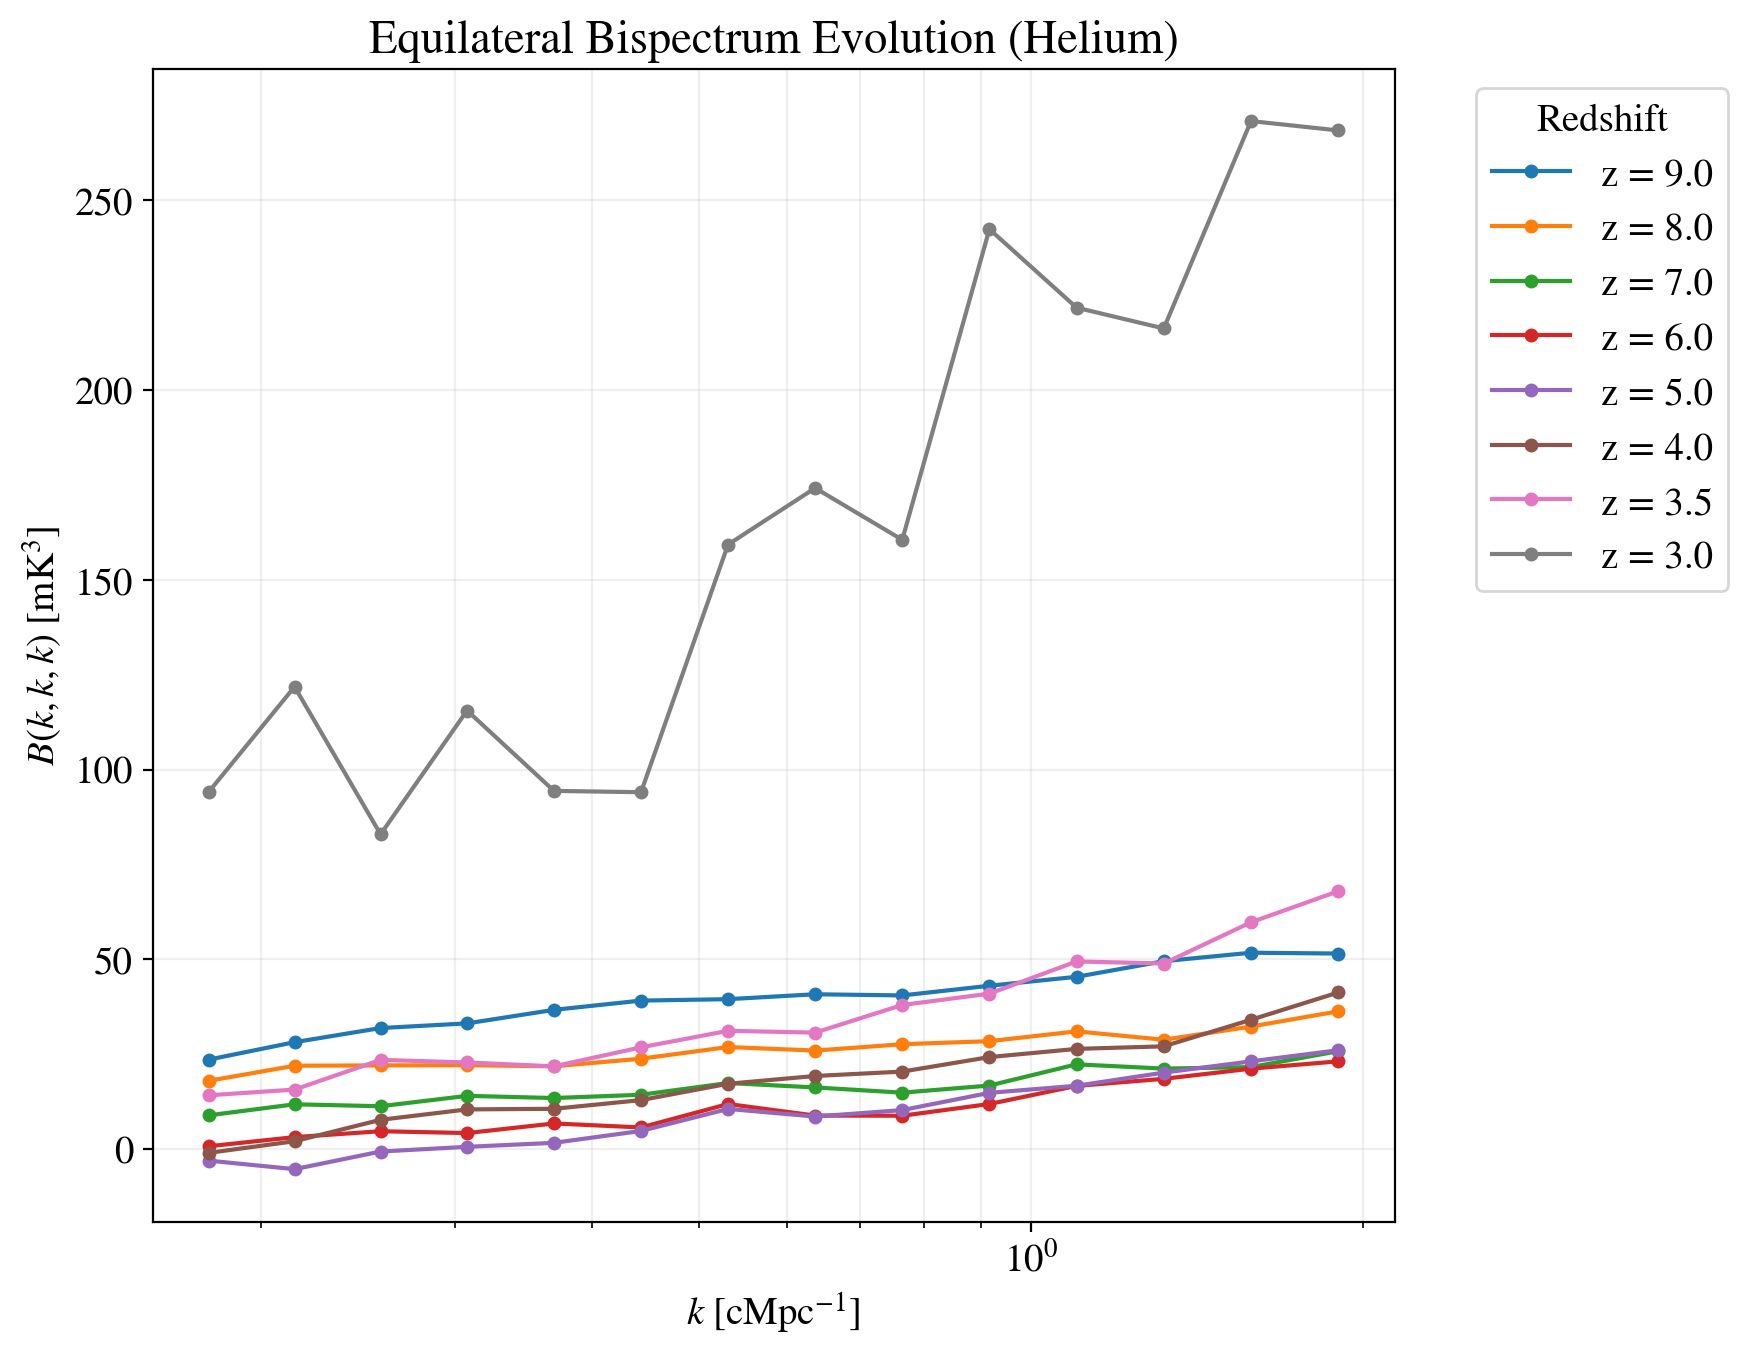

In [5]:
# =====================================
# Configuration & Mapping
# =====================================
z_map = {
    181: 9.0, 209: 8.0, 255: 7.0, 325: 6.0, 
    406: 5.0, 501: 4.0, 582: 3.5, 705: 3.0
}

snaps = [181, 209, 255, 325, 406, 501, 582, 705] #

plt.figure(figsize=(9, 7))

for snap in snaps:
    # Pointing to the "full" filename created in the previous step
    file = f"He_bispec_equilateral_full_{snap}.txt"

    if not os.path.exists(file):
        print(f"[SKIP] {file}")
        continue

    # Load the 10-column data
    data = np.loadtxt(file)
    if data.size == 0:
        continue
    
    data = np.atleast_2d(data)

    # UPDATED INDICES for the 10-column output:
    # Column 0: theta_over_pi
    # Column 1: k3 (this is your k)
    # Column 2: BS (this is your B)
    k = data[:, 1]
    B = data[:, 2]

    # Sort by k to ensure lines connect correctly
    idx = np.argsort(k)
    k_sorted = k[idx]
    B_sorted = B[idx]

    z = z_map[snap]

    # Plotting absolute value of B as it can sometimes be negative 
    # depending on the physics/fluctuations
    plt.plot(k_sorted, B_sorted, marker="o", markersize=4, label=f"z = {z}")

# =====================================
# Formatting for Cosmology
# =====================================
plt.xscale('log')
#plt.yscale('log') # Bispectra usually span several orders of magnitude

plt.xlabel(r"$k \ [\mathrm{cMpc}^{-1}]$")
plt.ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$") # \ cMpc^6
plt.title("Equilateral Bispectrum Evolution (Helium)")

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Redshift", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Optional: Save the plot
# plt.savefig("equilateral_bispectrum_plot.png", dpi=300)
plt.show()

## Equilateral (THESAN-1 Hydrogen)

In [13]:
# =====================================
# Configuration
# =====================================
snaps = [105, 139, 182, 240, 318, 369]
base_path = "/orcd/data/mvogelsb/004/chcho/PS_21cm/past/original/Thesan-1"
BOX_LEN = 95.5

z_map = {
    105: 10.0,
    139: 9.0,
    182: 8.0,
    240: 7.0,
    318: 6.0,
    369: 5.5
}

# Wavenumber range of interest
k_min, k_max = 0.15, 2.0

# =====================================
# Loop over snapshots
# =====================================
for snap in snaps:
    file_path = f"{base_path}/H_Tb_{snap:03d}.hdf5"

    if not os.path.exists(file_path):
        print(f"[SKIP] {file_path}")
        continue

    print(f"\n=== Snapshot {snap} ===")

    with h5py.File(file_path, 'r') as f:
        dT_box = np.array(f["Tb"][:])

    BOX_DIM = dT_box.shape[0]

    # Calculate exactly as the example does
    BS_equi_dict = bifft.calculate_equi_bipec(
        data=dT_box, 
        DIM=[BOX_DIM], 
        LEN=[BOX_LEN], 
        normalise=True
    )

    # Filter based on k3 (the primary k-scale for equilateral) within your range
    k3_vals = np.array(BS_equi_dict["k3"])
    mask = (k3_vals >= k_min) & (k3_vals <= k_max)

    # =====================================
    # Save all columns from the example
    # =====================================
    out_file = f"bispec_equilateral_full_{snap}_THESAN-1.txt"
    
    header = ("theta_over_pi\tk3\tBS_real\tBS_imag\tk1\tk2\tP1\tP2\tP3\tNtri")
    
    # We stack all the keys mentioned in your assert statements
    data_to_save = np.column_stack((
        np.array(BS_equi_dict["theta_over_pi"])[mask],
        np.array(BS_equi_dict["k3"])[mask],
        np.array(BS_equi_dict["BS"])[mask],
        np.array(BS_equi_dict["BSimag"])[mask],
        np.array(BS_equi_dict["k1"])[mask],
        np.array(BS_equi_dict["k2"])[mask],
        np.array(BS_equi_dict["P1"])[mask],
        np.array(BS_equi_dict["P2"])[mask],
        np.array(BS_equi_dict["P3"])[mask],
        np.array(BS_equi_dict["Ntri"])[mask]
    ))

    np.savetxt(out_file, data_to_save, header=header, fmt='%.6e', delimiter='\t')

    print(f"Saved complete dictionary data to: {out_file}")
    del dT_box


=== Snapshot 105 ===


 bispec.cc::equi_bispec -> kmax = 16.84


Saved complete dictionary data to: bispec_equilateral_full_105_THESAN-1.txt

=== Snapshot 139 ===


 bispec.cc::equi_bispec -> kmax = 16.84


Saved complete dictionary data to: bispec_equilateral_full_139_THESAN-1.txt

=== Snapshot 182 ===


...

Saved complete dictionary data to: bispec_equilateral_full_240_THESAN-1.txt

=== Snapshot 318 ===


 bispec.cc::equi_bispec -> kmax = 16.84


Saved complete dictionary data to: bispec_equilateral_full_318_THESAN-1.txt

=== Snapshot 369 ===


 bispec.cc::equi_bispec -> kmax = 16.84


Saved complete dictionary data to: bispec_equilateral_full_369_THESAN-1.txt


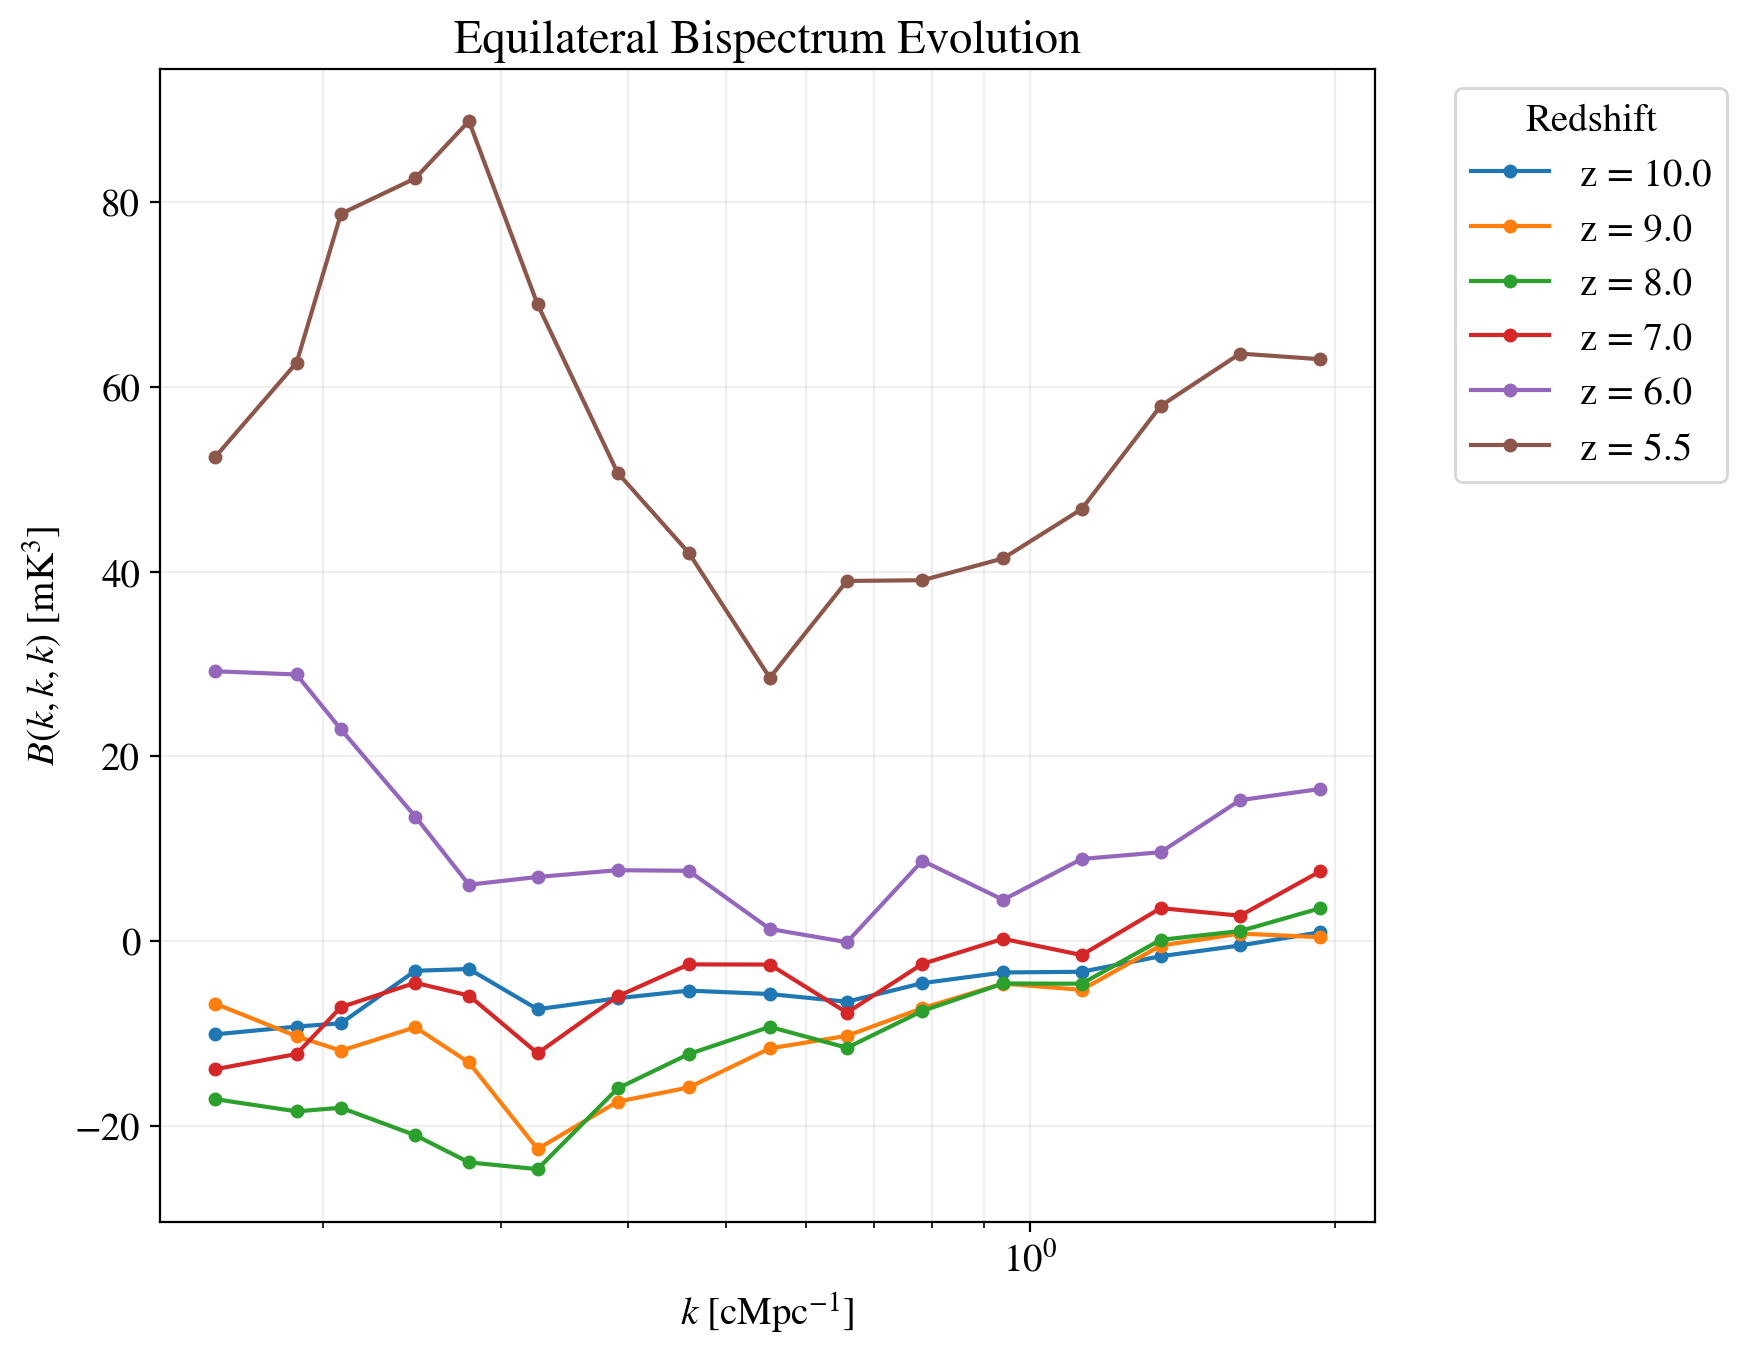

In [14]:
plt.figure(figsize=(9, 7))

for snap in snaps:
    # Pointing to the "full" filename created in the previous step
    file = f"bispec_equilateral_full_{snap}_THESAN-1.txt"

    if not os.path.exists(file):
        print(f"[SKIP] {file}")
        continue

    # Load the 10-column data
    data = np.loadtxt(file)
    if data.size == 0:
        continue
    
    data = np.atleast_2d(data)

    # UPDATED INDICES for the 10-column output:
    # Column 0: theta_over_pi
    # Column 1: k3 (this is your k)
    # Column 2: BS (this is your B)
    k = data[:, 1]
    B = data[:, 2]

    # Sort by k to ensure lines connect correctly
    idx = np.argsort(k)
    k_sorted = k[idx]
    B_sorted = B[idx]

    z = z_map[snap]

    # Plotting absolute value of B as it can sometimes be negative 
    # depending on the physics/fluctuations
    plt.plot(k_sorted, B_sorted, marker="o", markersize=4, label=f"z = {z}")

# =====================================
# Formatting for Cosmology
# =====================================
plt.xscale('log')
#plt.yscale('log') # Bispectra usually span several orders of magnitude

plt.xlabel(r"$k \ [\mathrm{cMpc}^{-1}]$")
plt.ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$") # \ cMpc^6
plt.title("Equilateral Bispectrum Evolution")

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Redshift", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Optional: Save the plot
# plt.savefig("equilateral_bispectrum_plot.png", dpi=300)
plt.show()

## Equilateral (THESAN-2 Hydrogen)

In [ ]:
# =====================================
# Configuration
# =====================================
snaps = [136, 170, 213, 271, 349, 400]
base_path = "/orcd/data/mvogelsb/004/chcho/PS_21cm/past/original/Thesan-2"
BOX_LEN = 95.5

z_map = {
    136: 10.0,
    170: 9.0,
    213: 8.0,
    271: 7.0,
    349: 6.0,
    400: 5.5
}

# Wavenumber range of interest
k_min, k_max = 0.15, 2.0

# =====================================
# Loop over snapshots
# =====================================
for snap in snaps:
    file_path = f"{base_path}/H_Tb_{snap:03d}.hdf5"

    if not os.path.exists(file_path):
        print(f"[SKIP] {file_path}")
        continue

    print(f"\n=== Snapshot {snap} ===")

    with h5py.File(file_path, 'r') as f:
        dT_box = np.array(f["Tb"][:])

    BOX_DIM = dT_box.shape[0]

    # Calculate exactly as the example does
    BS_equi_dict = bifft.calculate_equi_bipec(
        data=dT_box, 
        DIM=[BOX_DIM], 
        LEN=[BOX_LEN], 
        normalise=True
    )

    # Filter based on k3 (the primary k-scale for equilateral) within your range
    k3_vals = np.array(BS_equi_dict["k3"])
    mask = (k3_vals >= k_min) & (k3_vals <= k_max)

    # =====================================
    # Save all columns from the example
    # =====================================
    out_file = f"bispec_equilateral_full_{snap}_THESAN-2.txt"
    
    header = ("theta_over_pi\tk3\tBS_real\tBS_imag\tk1\tk2\tP1\tP2\tP3\tNtri")
    
    # We stack all the keys mentioned in your assert statements
    data_to_save = np.column_stack((
        np.array(BS_equi_dict["theta_over_pi"])[mask],
        np.array(BS_equi_dict["k3"])[mask],
        np.array(BS_equi_dict["BS"])[mask],
        np.array(BS_equi_dict["BSimag"])[mask],
        np.array(BS_equi_dict["k1"])[mask],
        np.array(BS_equi_dict["k2"])[mask],
        np.array(BS_equi_dict["P1"])[mask],
        np.array(BS_equi_dict["P2"])[mask],
        np.array(BS_equi_dict["P3"])[mask],
        np.array(BS_equi_dict["Ntri"])[mask]
    ))

    np.savetxt(out_file, data_to_save, header=header, fmt='%.6e', delimiter='\t')

    print(f"Saved complete dictionary data to: {out_file}")
    del dT_box


=== Snapshot 136 ===


 bispec.cc::equi_bispec -> kmax = 16.84


In [ ]:
plt.figure(figsize=(9, 7))

for snap in snaps:
    # Pointing to the "full" filename created in the previous step
    file = f"bispec_equilateral_full_{snap}_THESAN-2.txt"

    if not os.path.exists(file):
        print(f"[SKIP] {file}")
        continue

    # Load the 10-column data
    data = np.loadtxt(file)
    if data.size == 0:
        continue
    
    data = np.atleast_2d(data)

    # UPDATED INDICES for the 10-column output:
    # Column 0: theta_over_pi
    # Column 1: k3 (this is your k)
    # Column 2: BS (this is your B)
    k = data[:, 1]
    B = data[:, 2]

    # Sort by k to ensure lines connect correctly
    idx = np.argsort(k)
    k_sorted = k[idx]
    B_sorted = B[idx]

    z = z_map[snap]

    # Plotting absolute value of B as it can sometimes be negative 
    # depending on the physics/fluctuations
    plt.plot(k_sorted, B_sorted, marker="o", markersize=4, label=f"z = {z}")

# =====================================
# Formatting for Cosmology
# =====================================
plt.xscale('log')
#plt.yscale('log') # Bispectra usually span several orders of magnitude

plt.xlabel(r"$k \ [\mathrm{cMpc}^{-1}]$")
plt.ylabel(r"$B(k,k,k) \ [\mathrm{mK}^3]$") # \ cMpc^6
plt.title("Equilateral Bispectrum Evolution")

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Redshift", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Optional: Save the plot
# plt.savefig("equilateral_bispectrum_plot.png", dpi=300)
plt.show()

## General Bispectrum

In [9]:
# =====================================
# Load your data
# =====================================
snap = 255
file_path = f"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb/Tb_H_{snap:03d}.hdf5"

with h5py.File(file_path, 'r') as f:
    dT_box = f["rin"][:]

# =====================================
# Simulation setup
# =====================================
BOX_DIM = dT_box.shape[0]   # 640
BOX_LEN = 500.0             # cMpc

# =====================================
# General bispectrum
# =====================================
BS_gen = bifft.calculate_general_bipec(
    data=dT_box,
    DIM=[BOX_DIM],
    LEN=[BOX_LEN],
    k_1=0.2,
    k_2=0.2,
    normalise=True
)

# =====================================
# Quick check
# =====================================
print("Available keys:", BS_gen.keys())
print("theta/pi:", BS_gen["theta_over_pi"][:5])
print("k3:", BS_gen["k3"][:5])
print("BS:", BS_gen["BS"][:5])

Available keys: dict_keys(['theta_over_pi', 'k3', 'BS', 'BSimag', 'k1', 'k2', 'P1', 'P2', 'P3', 'Ntri'])
theta/pi: [0.05       0.1        0.2        0.33333334 0.4       ]
k3: [0.03822723 0.06712851 0.12637919 0.20151309 0.23658747]
BS: [-23.60977803 -16.83859311 -17.63787525 -23.08178098 -23.52665233]


In [ ]:
out_file = "bispec_general_z10_TSTK.txt"

with open(out_file, "w") as f:
    for i in range(len(BS_gen["theta_over_pi"])):
        f.write(
            "{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n".format(
                BS_gen["theta_over_pi"][i],
                BS_gen["k3"][i],
                BS_gen["BS"][i],
                BS_gen["BSimag"][i],
                BS_gen["k1"][i],
                BS_gen["k2"][i],
                BS_gen["P1"][i],
                BS_gen["P2"][i],
                BS_gen["P3"][i],
                BS_gen["Ntri"][i],
            )
        )

print("Saved:", out_file)

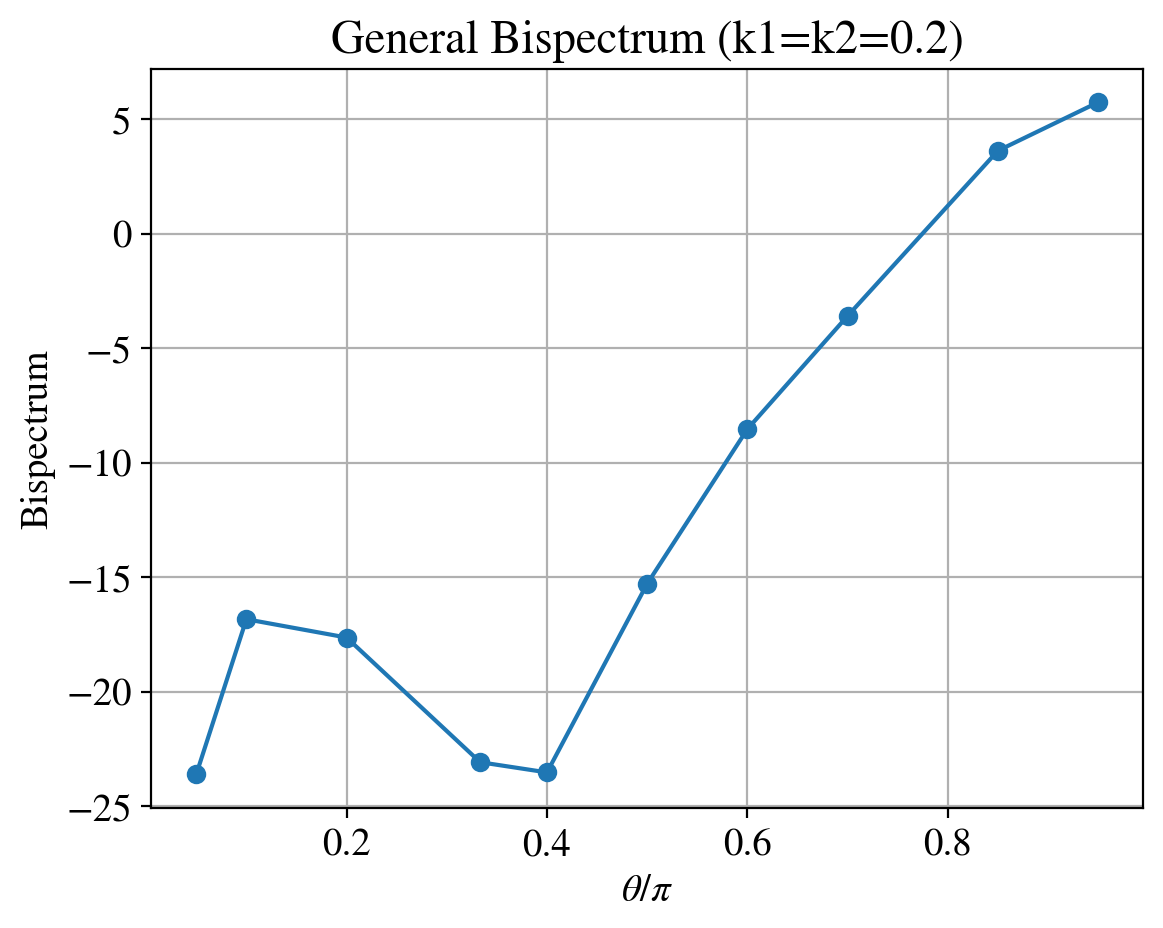

In [11]:
theta = BS_gen["theta_over_pi"]
B = BS_gen["BS"]

plt.plot(theta, B, marker="o")
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Bispectrum")
plt.title("General Bispectrum (k1=k2=0.2)")
plt.grid()
plt.show()

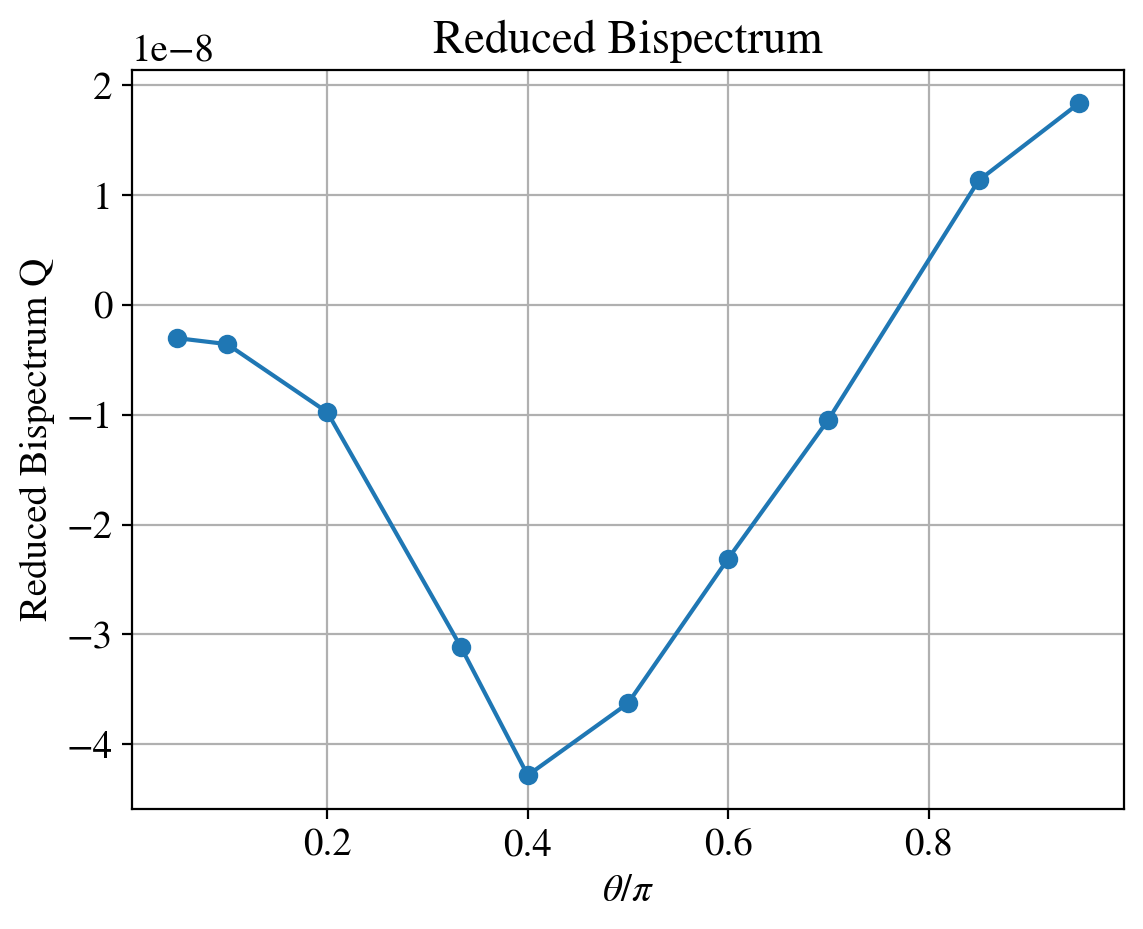

In [12]:
P1 = BS_gen["P1"]
P2 = BS_gen["P2"]
P3 = BS_gen["P3"]

Q = B / (P1*P2 + P2*P3 + P3*P1)

plt.plot(theta, Q, marker="o")
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Reduced Bispectrum Q")
plt.title("Reduced Bispectrum")
plt.grid()
plt.show()

## Power Spectrum (Same as our previous calculation.)

In [7]:
snap = 255 # redshift 10.01
file_path = f"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb/Tb_H_{snap:03d}.hdf5"

with h5py.File(file_path, 'r') as f:
    # Assuming the data ranges from 0.0 (neutral) to 1.0 (ionized)
    dT_box = f["rin"][:]

BOX_DIM = 640
BOX_LEN = 500.0

pspec_dict = bifft.calculate_pspec(
    data=dT_box,
    DIM=[BOX_DIM],
    LEN=[BOX_LEN],
    normalise=True
)

print("k:", pspec_dict["k"][:5])
print("Pk:", pspec_dict["Pk"][:5])

plt.loglog(pspec_dict["k"], pspec_dict["Pk"], label="P(k)")
plt.fill_between(
    pspec_dict["k"],
    pspec_dict["Pk"] - pspec_dict["Pkerr"],
    pspec_dict["Pk"] + pspec_dict["Pkerr"],
    alpha=0.3
)

plt.xlabel("k")
plt.ylabel("P(k)")
plt.legend()
plt.show()

k: [0.01256637 0.01777153 0.02176559 0.02513274 0.02809926]
Pk: [0.10545055 0.319998   0.37329605 1.0723834  0.75868964]


## Example test

In [12]:
snap = 255 # redshift 10.01
file_path = f"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb/Tb_H_{snap:03d}.hdf5"

with h5py.File(file_path, 'r') as f:
    # Assuming the data ranges from 0.0 (neutral) to 1.0 (ionized)
    dT_box = f["rin"][:]

BOX_DIM = 640
BOX_LEN = 500.0

# Run bispectrum
BS_gen_dict = bifft.calculate_general_bipec(
    data=dT_box,
    DIM=[BOX_DIM],
    LEN=[BOX_LEN],
    k_1=0.15,
    k_2=0.30,
    normalise=True
)

print("Keys:", BS_gen_dict.keys())
print("theta/pi:", BS_gen_dict["theta_over_pi"][:5])
print("k3:", BS_gen_dict["k3"][:5])
print("BS:", BS_gen_dict["BS"][:5])

Keys: dict_keys(['theta_over_pi', 'k3', 'BS', 'BSimag', 'k1', 'k2', 'P1', 'P2', 'P3', 'Ntri'])
theta/pi: [0.01       0.05       0.1        0.2        0.33333334]
k3: [0.16954553 0.17492896 0.18416073 0.21371704 0.27424615]
BS: [4.1032204  4.08764924 4.11559927 4.91996108 6.48432865]


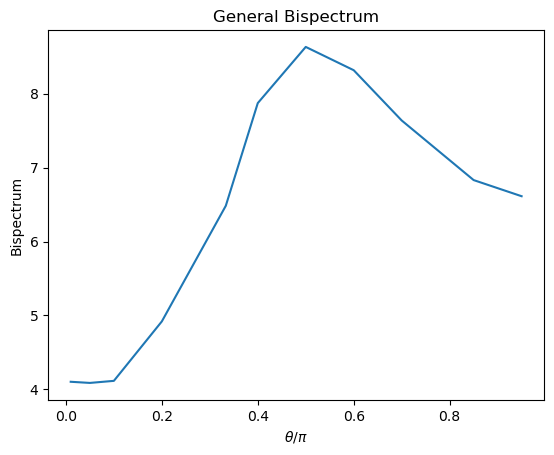

In [13]:
import matplotlib.pyplot as plt

theta = BS_gen_dict["theta_over_pi"]
BS = BS_gen_dict["BS"]

plt.plot(theta, BS)
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Bispectrum")
plt.title("General Bispectrum")
plt.show()

In [14]:
import numpy as np
import pickle
import os
import bifft

BOX_DIM = 64
BOX_LEN = BOX_DIM * 2.0

BASE = "/home/chcho/apps/bifft"
TEST_DATA_FNAME = os.path.join(BASE, "Tests/brightness_temp_test_data.pkl")
OUT_FILE = os.path.join(BASE, "Tests/bispec_output.txt")

# Load data
with open(TEST_DATA_FNAME, "rb") as f:
    dT_box = np.array(pickle.load(f))

# Run bispectrum
BS_gen_dict = bifft.calculate_general_bipec(
    data=dT_box,
    DIM=[BOX_DIM],
    LEN=[BOX_LEN],
    k_1=0.15,
    k_2=0.30,
    normalise=True
)

# Write output (THIS is what you want)
with open(OUT_FILE, "w") as fout:
    for i in range(len(BS_gen_dict["theta_over_pi"])):
        fout.write(
            "{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n".format(
                BS_gen_dict["theta_over_pi"][i],
                BS_gen_dict["k3"][i],
                BS_gen_dict["BS"][i],
                BS_gen_dict["BSimag"][i],
                BS_gen_dict["k1"][i],
                BS_gen_dict["k2"][i],
                BS_gen_dict["P1"][i],
                BS_gen_dict["P2"][i],
                BS_gen_dict["P3"][i],
                BS_gen_dict["Ntri"][i],
            )
        )

print("Saved to:", OUT_FILE)

Saved to: /home/chcho/apps/bifft/Tests/bispec_output.txt


In [15]:
dir(bifft)

['BasicContext',
 'Clamped',
 'Context',
 'ConversionSyntax',
 'DEBUG',
 'Decimal',
 'DecimalException',
 'DecimalTuple',
 'DefaultContext',
 'DivisionByZero',
 'DivisionImpossible',
 'DivisionUndefined',
 'ExtendedContext',
 'FloatOperation',
 'Function_21cmPS',
 'Function_BS_cylin',
 'Function_BS_equi',
 'Function_BS_general',
 'Function_BS_isoc',
 'HAVE_CONTEXTVAR',
 'HAVE_THREADS',
 'IEEEContext',
 'IEEE_CONTEXT_MAX_BITS',
 'Inexact',
 'InvalidContext',
 'InvalidOperation',
 'Lib_21cmPS',
 'Lib_BS_cylin',
 'Lib_BS_equi',
 'Lib_BS_general',
 'Lib_BS_isoc',
 'MAX_EMAX',
 'MAX_PREC',
 'MIN_EMIN',
 'MIN_ETINY',
 'Overflow',
 'PSPoint',
 'PointBScylin',
 'PointBSequi',
 'PointBSgen',
 'PointBSisoc',
 'ROUND_05UP',
 'ROUND_CEILING',
 'ROUND_DOWN',
 'ROUND_FLOOR',
 'ROUND_HALF_DOWN',
 'ROUND_HALF_EVEN',
 'ROUND_HALF_UP',
 'ROUND_UP',
 'Rounded',
 'SOURCE_FOLDER',
 'SharedLibraryLocation',
 'Subnormal',
 'TWOPLACES',
 'Underflow',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '

In [ ]:
import numpy as np
import h5py
import bifft
import os

# =====================================
# Snapshot list
# =====================================
snaps = [156, 181, 209, 255, 289, 325, 364, 406]

base_path = "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb"

BOX_LEN = 500.0
k_target = 0.2   # target k for equilateral
tol = 0.02       # tolerance for k3 ~ k1

# =====================================
# Loop over snapshots
# =====================================
for snap in snaps:

    file_path = f"{base_path}/Tb_H_{snap:03d}.hdf5"

    if not os.path.exists(file_path):
        print(f"[SKIP] File not found: {file_path}")
        continue

    print(f"\n=== Processing snapshot {snap} ===")

    # ---------------------------------
    # Load data
    # ---------------------------------
    with h5py.File(file_path, 'r') as f:
        dT_box = f["rin"][:]

    BOX_DIM = dT_box.shape[0]

    # ---------------------------------
    # Run bispectrum (isosceles base)
    # ---------------------------------
    BS = bifft.calculate_isoc_bipec(
        data=dT_box,
        DIM=[BOX_DIM],
        LEN=[BOX_LEN],
        k_1=k_target,
        normalise=True
    )

    # ---------------------------------
    # Select equilateral: k3 ≈ k1
    # ---------------------------------
    k3 = np.array(BS["k3"])
    mask = np.abs(k3 - k_target) < tol

    # ---------------------------------
    # Save output
    # ---------------------------------
    out_file = f"bispec_equilateral_{snap}_TSTK.txt"

    with open(out_file, "w") as f:
        for i in np.where(mask)[0]:
            f.write(
                "{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n".format(
                    BS["k3"][i],
                    BS["BS"][i],
                    BS["BSimag"][i],
                    BS["k1"][i],
                    BS["k2"][i],
                    BS["P1"][i],
                    BS["P2"][i],
                    BS["P3"][i],
                    BS["Ntri"][i],
                    i
                )
            )

    # ---------------------------------
    # Debug output
    # ---------------------------------
    print("Saved:", out_file)
    print("Selected k3:", k3[mask][:3])
    print("Selected BS:", np.array(BS["BS"])[mask][:3])

    del dT_box, BS


# =====================================
# Redshift mapping
# =====================================
z_map = {
    156: 10.0,
    181: 9.0,
    209: 8.0,
    255: 7.0,
    289: 6.5,
    325: 6.0,
    364: 5.5,
    406: 5.0
}

snaps = [156, 181, 209, 255, 289, 325, 364, 406]

# =====================================
# Storage
# =====================================
z_list = []
B_list = []

# =====================================
# Loop over snapshots
# =====================================
for snap in snaps:

    file = f"bispec_equilateral_{snap}_TSTK.txt"

    if not os.path.exists(file):
        print(f"[SKIP] File not found: {file}")
        continue

    try:
        data = np.loadtxt(file)

        # Handle empty file
        if data.size == 0:
            print(f"[EMPTY] {file}")
            continue

        # Ensure 2D
        data = np.atleast_2d(data)

    except Exception as e:
        print(f"[ERROR] Could not read {file}: {e}")
        continue

    # ---------------------------------
    # Extract bispectrum
    # ---------------------------------
    B_vals = data[:, 1]

    # Average (since multiple rows may exist)
    B_mean = np.mean(B_vals)

    z_list.append(z_map[snap])
    B_list.append(B_mean)

# =====================================
# Convert to arrays & sort
# =====================================
z_arr = np.array(z_list)
B_arr = np.array(B_list)

if len(z_arr) == 0:
    raise RuntimeError("No valid data found!")

idx = np.argsort(z_arr)

# =====================================
# Plot
# =====================================
plt.figure(figsize=(8,6))

plt.plot(
    z_arr[idx],
    B_arr[idx],
    marker="o",
    linewidth=2
)

plt.xlabel("Redshift z")
plt.ylabel("Equilateral Bispectrum")
plt.title(r"Equilateral Bispectrum Evolution ($k = 0.2$)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
snap = 255
file_path = f"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb/Tb_H_{snap:03d}.hdf5"

with h5py.File(file_path, 'r') as f:
    dT_box = f["rin"][:]

BOX_DIM = dT_box.shape[0]
BOX_LEN = 500.0

k1 = 0.2
k2 = 0.2

BS_iso = bifft.calculate_isoc_bipec(   # ✅ correct name
    data=dT_box,
    DIM=[BOX_DIM],
    LEN=[BOX_LEN],
    k_1=k1,
    normalise=True
)

with open(f"bispec_isosceles_{snap}_TSTK.txt", "w") as f:
    for i in range(len(BS_iso["k3"])):
        f.write(
            "{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n".format(
                BS_iso["k3"][i],
                BS_iso["BS"][i],
                BS_iso["BSimag"][i],
                BS_iso["k1"][i],
                BS_iso["k2"][i],
                BS_iso["P1"][i],
                BS_iso["P2"][i],
                BS_iso["P3"][i],
                BS_iso["Ntri"][i],
                i
            )
        )

print("Keys:", BS_iso.keys())
print("k3:", BS_iso["k3"][:5])
print("BS:", BS_iso["BS"][:5])

Keys: dict_keys(['theta_over_pi', 'k3', 'BS', 'BSimag', 'k1', 'k2', 'P1', 'P2', 'P3', 'Ntri'])
k3: [0.03822723 0.06712851 0.12637919 0.20151309 0.23658747]
BS: [-23.60977803 -16.83859311 -17.63787525 -23.08178098 -23.52665233]


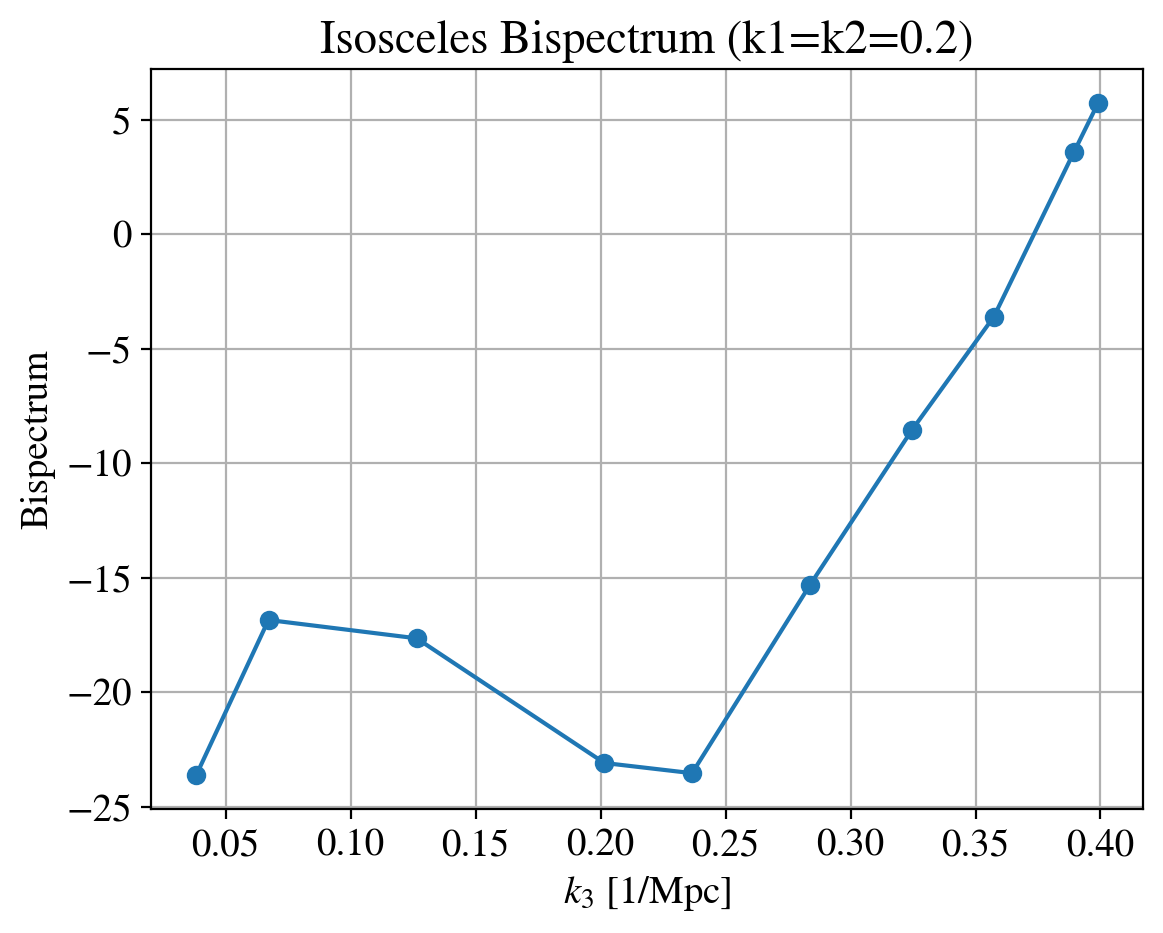

In [22]:
k3 = BS_iso["k3"]
B = BS_iso["BS"]

plt.plot(k3, B, marker="o")
plt.xlabel(r"$k_3$ [1/Mpc]")
plt.ylabel("Bispectrum")
plt.title("Isosceles Bispectrum (k1=k2=0.2)")
plt.grid()
plt.show()

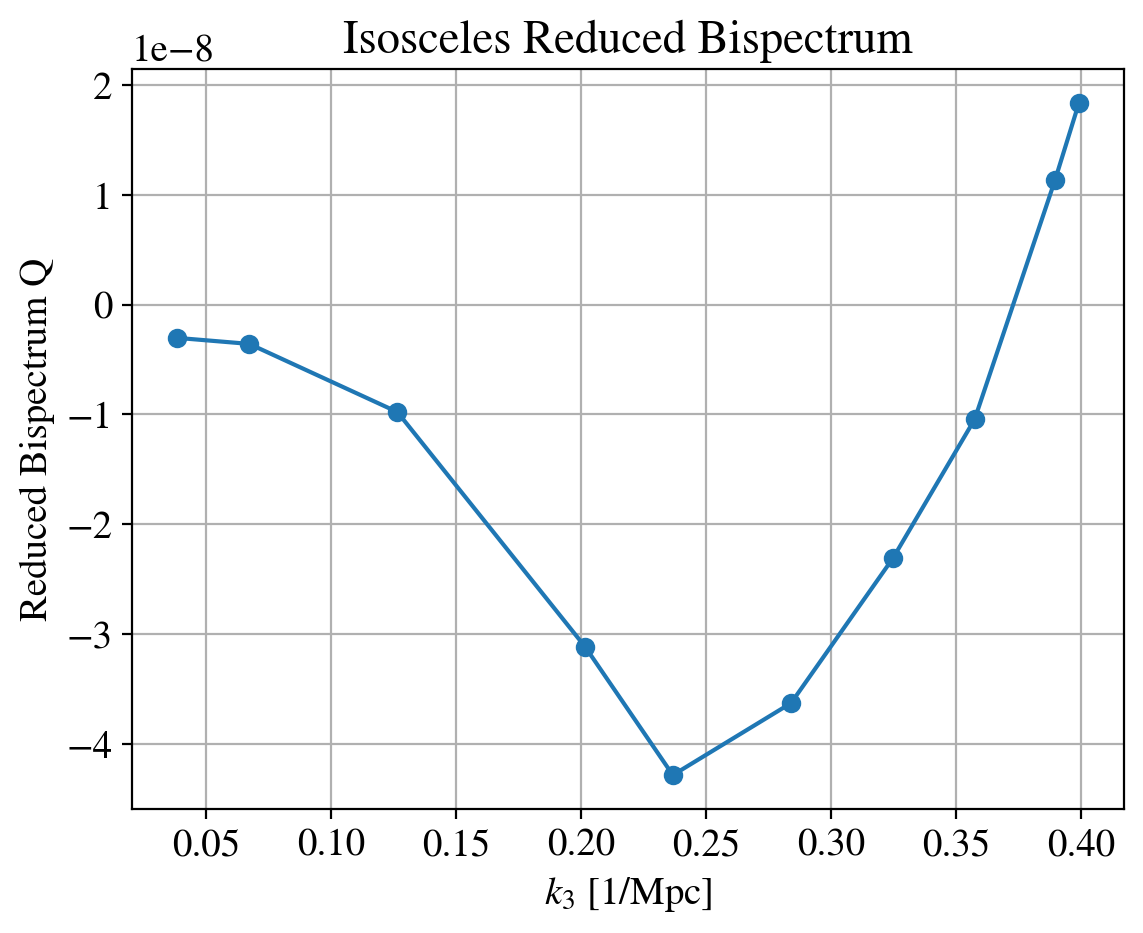

In [23]:
P1 = BS_iso["P1"]
P2 = BS_iso["P2"]
P3 = BS_iso["P3"]

Q = B / (P1*P2 + P2*P3 + P3*P1)

plt.plot(k3, Q, marker="o")
plt.xlabel(r"$k_3$ [1/Mpc]")
plt.ylabel("Reduced Bispectrum Q")
plt.title("Isosceles Reduced Bispectrum")
plt.grid()
plt.show()

In [28]:
k3 = BS_iso["k3"]

cos_theta = (k3**2 - k1**2 - k2**2) / (2 * k1 * k2)

# numerical safety
cos_theta = np.clip(cos_theta, -1.0, 1.0)

theta = np.arccos(cos_theta)

theta_over_pi = theta / np.pi

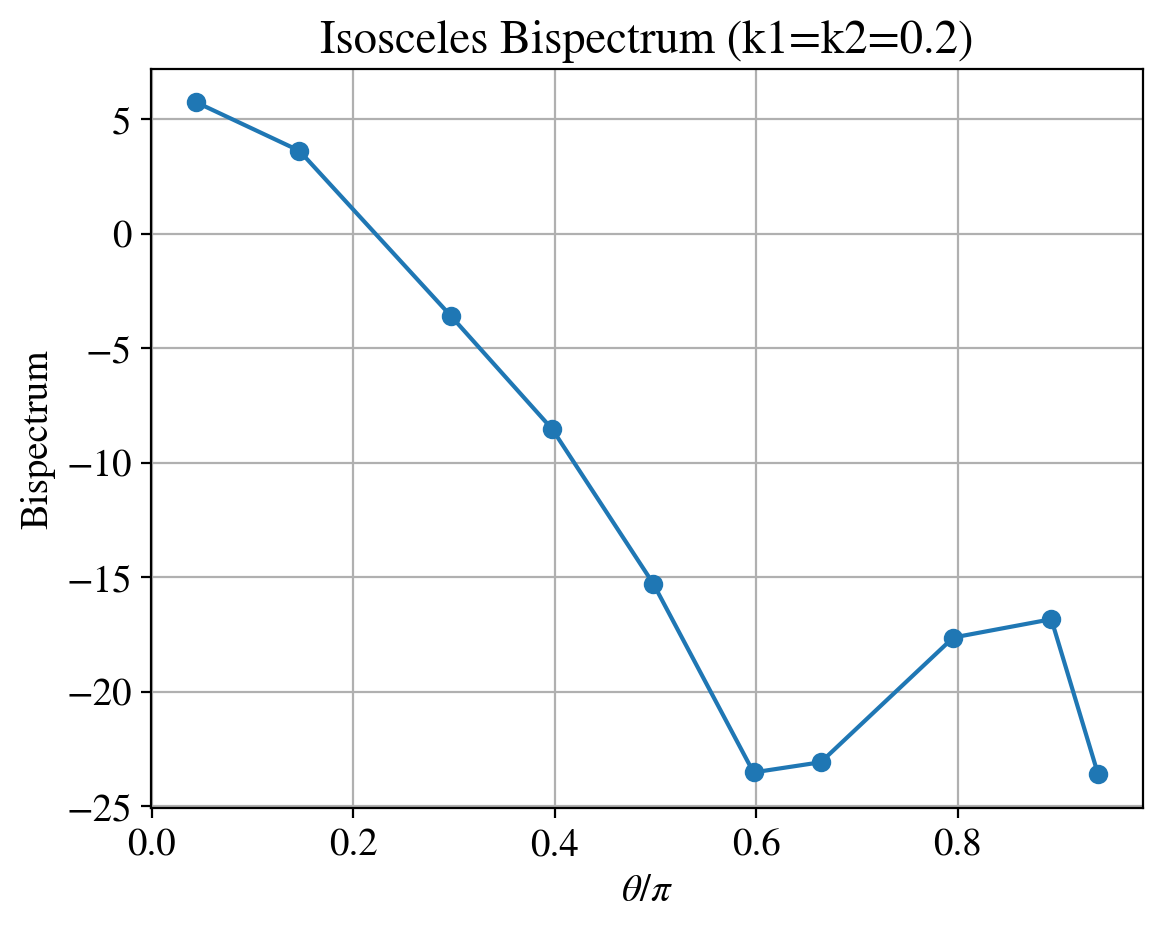

In [29]:
import matplotlib.pyplot as plt

B = BS_iso["BS"]

plt.plot(theta_over_pi, B, marker="o")
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Bispectrum")
plt.title("Isosceles Bispectrum (k1=k2=0.2)")
plt.grid()
plt.show()

In [24]:
import numpy as np
import h5py
import bifft
import matplotlib.pyplot as plt

# =====================================
# Load data
# =====================================
snap = 255
file_path = f"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb/Tb_H_{snap:03d}.hdf5"

with h5py.File(file_path, 'r') as f:
    dT_box = f["rin"][:]

# =====================================
# Setup
# =====================================
BOX_DIM = dT_box.shape[0]   # 640
BOX_LEN = 500.0             # cMpc

# =====================================
# Convert desired k → K_FAC
# =====================================
k_target = 0.2
k_min = 2 * np.pi / BOX_LEN
K_FAC = k_target / k_min

print("k_min =", k_min)
print("K_FAC =", K_FAC)

# =====================================
# Run equilateral bispectrum
# =====================================
BS_equi = bifft.calculate_equi_bipec(
    data=dT_box,
    DIM=[BOX_DIM],
    LEN=[BOX_LEN],
    K_FAC=K_FAC,
    normalise=True
)

# =====================================
# Inspect
# =====================================
print("Keys:", BS_equi.keys())
print("k3:", BS_equi["k3"][:5])
print("BS:", BS_equi["BS"][:5])

k_min = 0.012566370614359173
K_FAC = 15.915494309189533


 bispec.cc::equi_bispec -> kmax = 4.02


Keys: dict_keys(['theta_over_pi', 'k3', 'BS', 'BSimag', 'k1', 'k2', 'P1', 'P2', 'P3', 'Ntri'])
k3: [0.10895153 1.69267464]
BS: [-23.92326218   7.12163957]


In [25]:
with open("bispec_equilateral_z10_TSTK.txt", "w") as f:
    for k, B in zip(k_out, B_eq):
        f.write(f"{k}\t{B}\n")

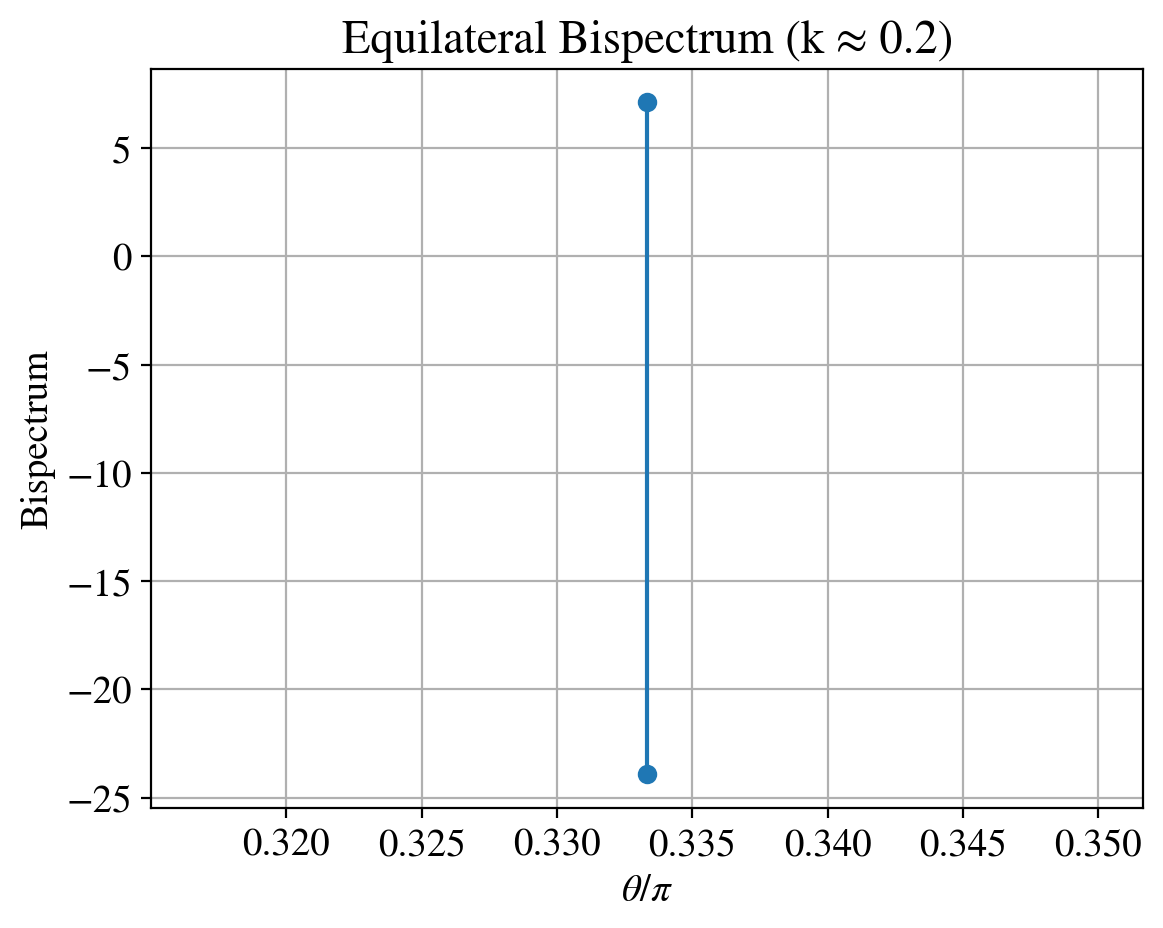

In [26]:
theta = BS_equi["theta_over_pi"]
B = BS_equi["BS"]

plt.plot(theta, B, marker="o")
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Bispectrum")
plt.title("Equilateral Bispectrum (k ≈ 0.2)")
plt.grid()
plt.show()

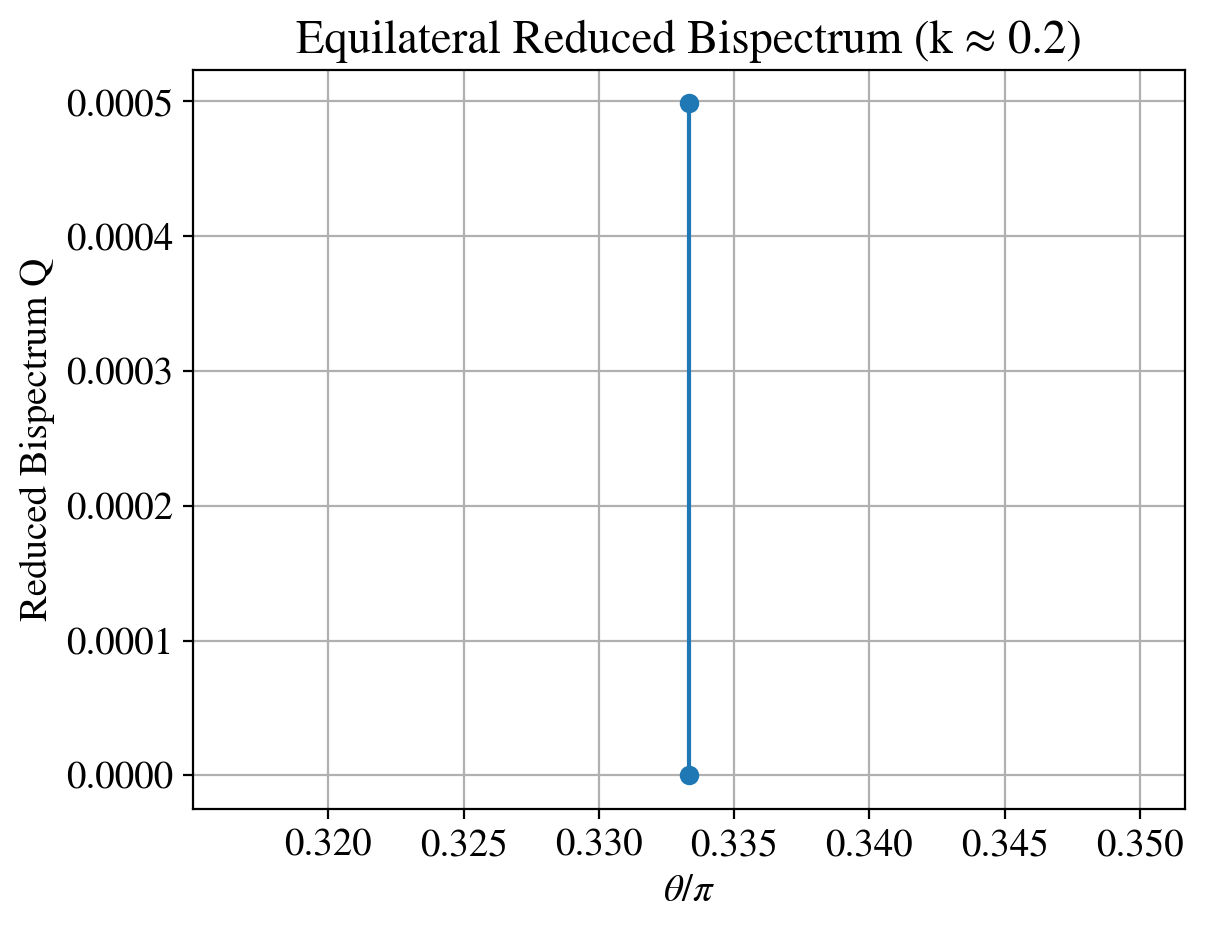

In [27]:
theta = BS_equi["theta_over_pi"]
B = BS_equi["BS"]

P1 = BS_equi["P1"]
P2 = BS_equi["P2"]
P3 = BS_equi["P3"]

Q = B / (P1*P2 + P2*P3 + P3*P1)

plt.plot(theta, Q, marker="o")
plt.xlabel(r"$\theta / \pi$")
plt.ylabel("Reduced Bispectrum Q")
plt.title("Equilateral Reduced Bispectrum (k ≈ 0.2)")
plt.grid()
plt.show()

In [32]:
import numpy as np
import h5py
import bifft
import matplotlib.pyplot as plt

# =====================================
# Load data
# =====================================
snap = 255
file_path = f"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb/Tb_H_{snap:03d}.hdf5"

with h5py.File(file_path, 'r') as f:
    dT_box = f["rin"][:]

# =====================================
# Setup
# =====================================
BOX_DIM = dT_box.shape[0]
BOX_LEN = 500.0

k_vals = np.linspace(0.15, 2.0, 15)

k_min = 2 * np.pi / BOX_LEN

B_eq = []
k_out = []

# =====================================
# Loop over k
# =====================================
for k in k_vals:
    K_FAC = k / k_min

    print(f"k = {k:.3f}, K_FAC = {K_FAC:.1f}")

    BS = bifft.calculate_equi_bipec(
        data=dT_box,
        DIM=[BOX_DIM],
        LEN=[BOX_LEN],
        K_FAC=K_FAC,
        normalise=True
    )

    # extract equilateral point
    theta = BS["theta_over_pi"]
    B = BS["BS"]

    idx = np.argmin(np.abs(theta - 2/3))

    B_eq.append(B[idx])
    k_out.append(k)

B_eq = np.array(B_eq)
k_out = np.array(k_out)

k = 0.150, K_FAC = 11.9


 bispec.cc::equi_bispec -> kmax = 4.02


k = 0.282, K_FAC = 22.5


 bispec.cc::equi_bispec -> kmax = 4.02


k = 0.414, K_FAC = 33.0


...

 bispec.cc::equi_bispec -> kmax = 4.02


k = 1.868, K_FAC = 148.6


 bispec.cc::equi_bispec -> kmax = 4.02


k = 2.000, K_FAC = 159.2


 bispec.cc::equi_bispec -> kmax = 4.02


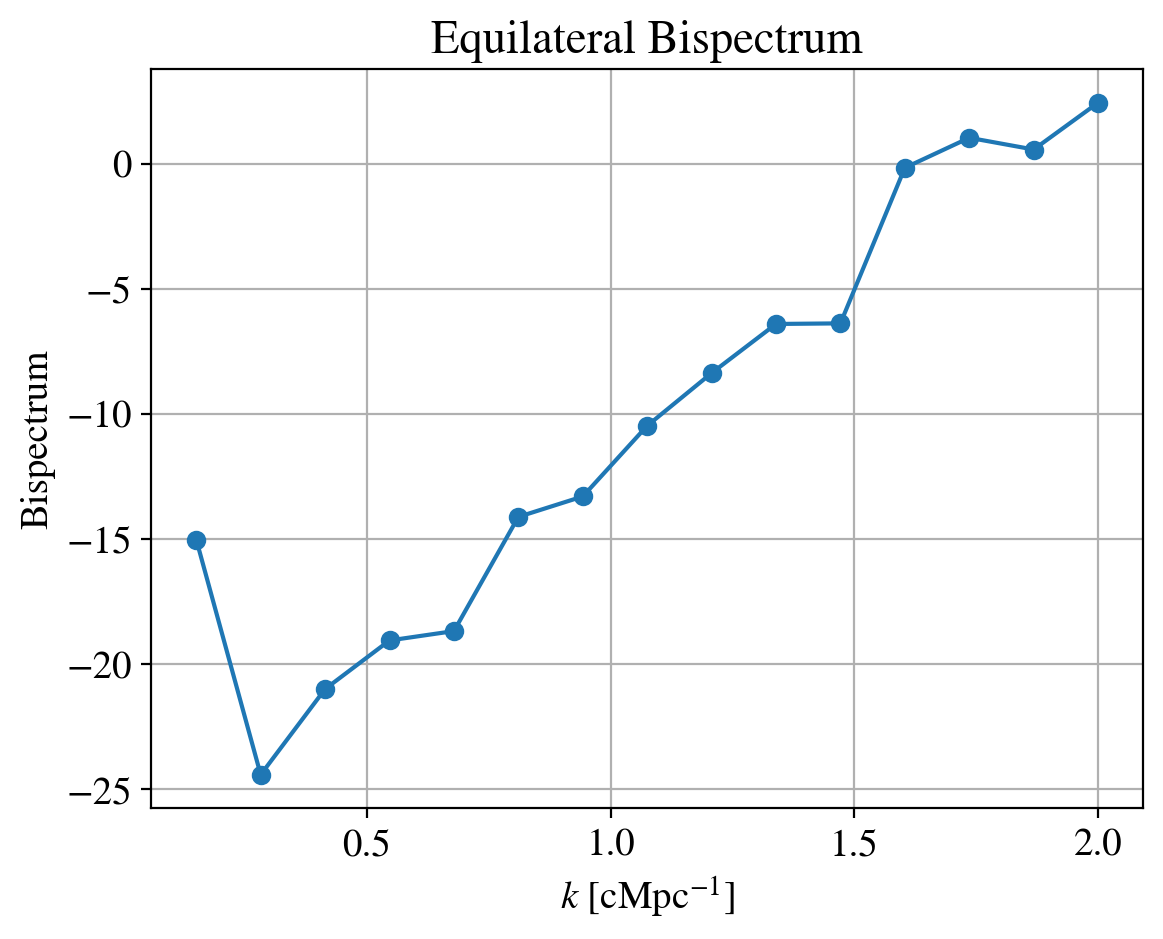

In [33]:
plt.plot(k_out, B_eq, marker="o")
plt.xlabel(r"$k$ [cMpc$^{-1}$]")
plt.ylabel("Bispectrum")
plt.title("Equilateral Bispectrum")
plt.grid()
plt.show()

 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02
 bispec.cc::equi_bispec -> kmax = 4.02


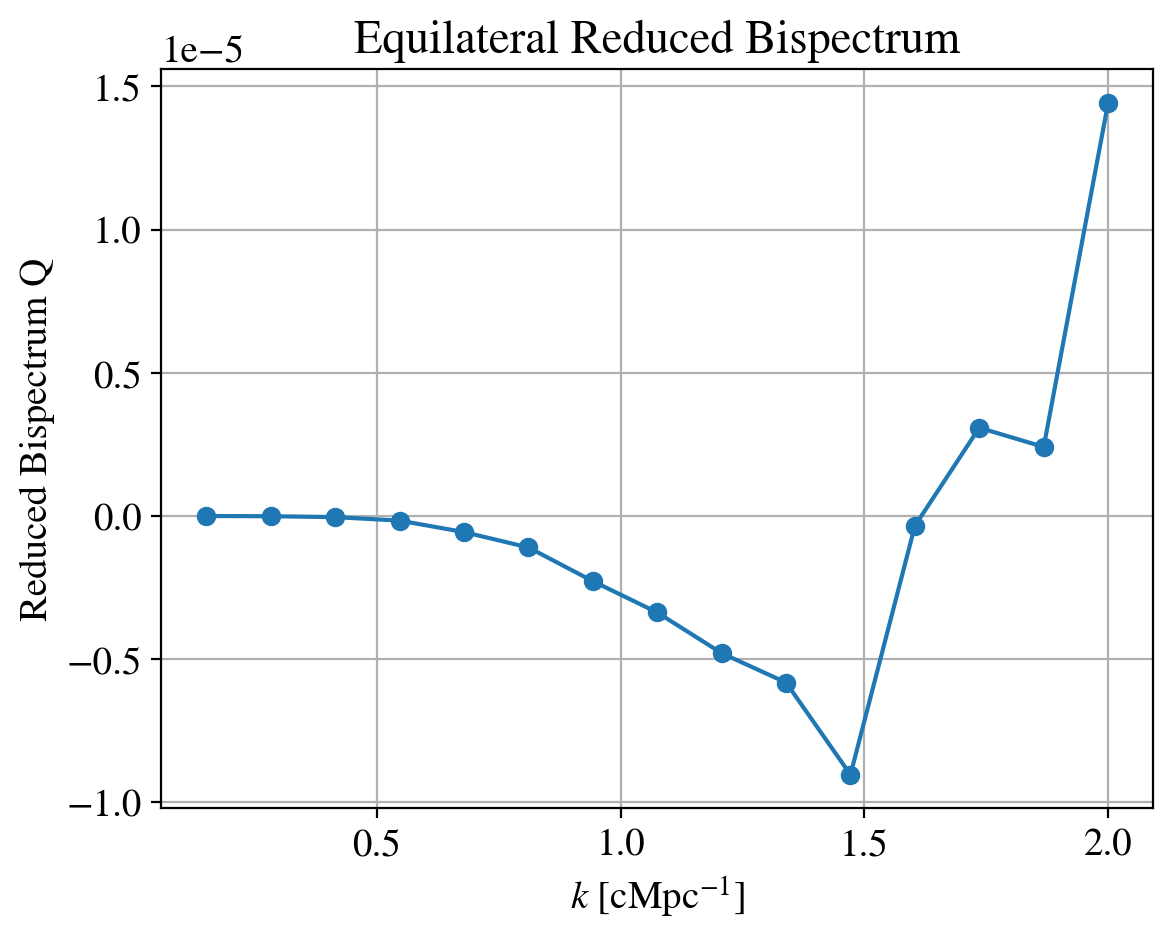

In [34]:
Q_eq = []

for k in k_vals:
    K_FAC = k / k_min

    BS = bifft.calculate_equi_bipec(
        data=dT_box,
        DIM=[BOX_DIM],
        LEN=[BOX_LEN],
        K_FAC=K_FAC,
        normalise=True
    )

    theta = BS["theta_over_pi"]
    idx = np.argmin(np.abs(theta - 2/3))

    B = BS["BS"][idx]
    P1 = BS["P1"][idx]
    P2 = BS["P2"][idx]
    P3 = BS["P3"][idx]

    denom = P1*P2 + P2*P3 + P3*P1
    Q_eq.append(B / denom if denom > 0 else 0)

Q_eq = np.array(Q_eq)

plt.plot(k_out, Q_eq, marker="o")
plt.xlabel(r"$k$ [cMpc$^{-1}$]")
plt.ylabel("Reduced Bispectrum Q")
plt.title("Equilateral Reduced Bispectrum")
plt.grid()
plt.show()